# Attenuator calibration and throughput noise lab

**Questions for this bench session:** where does the calibrated range end, how stable is a fixed
attenuator setting, and which measured fluctuations could be explained by its drive voltage?

The physical model is the existing **erf shutter model**. This notebook uses one SciPy optimizer.
It explores which measured points should influence the base fit and its Chebyshev correction;
it does not compare alternate physical models or reproduce the firmware optimizer.

1. [Setup and raw calibration](#setup): archive measurements before analysis.
2. [Fit-range experiments](#fits): compare full-range, correction-limited, and range-limited fits.
3. [Fixed-setting acquisitions](#acquire): dark, 25+35 / 25+25 / 25+35, and equal-total redistribution.
4. [Noise and throughput](#noise): timestamps, scatter, spectra, averaging, and route/error accounting.
5. [Drive-voltage evidence](#scope): local slopes, bandwidth scenarios, and simultaneous scope traces.

**Section 2 reads saved data only.** Use the workspace `.venv` kernel. Hardware cells use the
setup flags; inspect their current values before Run All.
The laser-on approval flags must remain false until the operator approves that acquisition.
No exploratory coefficients are uploaded. The optional embedded calibration does install its own
accepted fit in RAM, even with `persist=False`; it may drive the laser up to 100%.

Raw files created during acquisition live in `tools/atten_noise_data/`. Keep these with the setup
metadata: a plot or coefficient tuple alone cannot support a later refit.

## Starting evidence

For the supplied bypass experiment, take the stable laser, both isolators, 25 dB static attenuation,
and direct FVOA2-to-detector connection as the experimental setup. The apparent ~8 mV scope variation
is near the instrument floor; it is **not** an established drive-voltage RMS or bandwidth.

The earlier investigation reported the following fixed-current intervals. These are transcribed
observations, **not recalculated from the CSVs currently on disk**:

| Programmed dB | Mean net ADC (mV) | RMS scatter (mV) | Relative RMS |
|---|---:|---:|---:|
| 25 + 35, first | 145.46 | 13.77 | 9.46% |
| 25 + 25 | 1359.05 | 98.82 | 7.27% |
| 25 + 35, repeat | 129.48 | 6.70 | 5.18% |

Drift and correlation were substantial. The last two means differ by 10.50×, versus 14.74× in RMS;
shot noise alone would predict a 3.24× RMS ratio. A constant percentage fluctuation is a useful
comparison, but does not identify the component producing it.

Three quantities remain separate throughout this notebook: **temporal scatter**, **repeatability of
an average**, and **shared calibration uncertainty**. Firmware `tp_err` is an uncertainty budget,
not a measurement of illuminated temporal scatter. Its assumed 10 mV FVOA term is a hypothesis to
test, not evidence that the drive actually has that noise.

<a id="setup"></a>
## 1. Setup

`laser(value=0)` now retains driver readiness. Cleanup uses `laser(stop=True)` for explicit shutdown.
The new firmware/helper must be used together; restart the kernel after updating the helper.

Keep the launch power fixed during each illuminated sequence. Equal-total allocations compare
different local FVOA slopes at approximately the same detector level. Repeated reference settings
reveal drift and hysteresis. Record physical changes in `SETUP_NOTES` before each acquisition.

In [1]:
from pathlib import Path
from dataclasses import asdict, is_dataclass
from datetime import datetime, timezone
import json
import math
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import signal

TOOLS = next(p.resolve() for p in (Path.cwd(), Path.cwd() / "tools", Path.cwd() / "hispec-tib/tools") if (p / "hispec_fibpcb.py").is_file())
sys.path.insert(0, str(TOOLS))
import hispec_fibpcb as hspcb

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.2})
DATA_DIR = TOOLS / "atten_noise_data"
BROKER, DEVICE = "hispec.caltech.edu", "hsfib-tib"
LASER, CHANNEL, OUTPUT, FIBER = "1028y", "yj", "yj_ao", "M"
CONNECT = True
FETCH_CALIBRATION = True
RUN_AUTOCAL = True
AUTOCAL_LASER_APPROVED = True  # Includes the firmware's possible 100% laser setting.
RUN_NOISE_SEQUENCE = True
NOISE_LASER_APPROVED = True
UPDATE_STATIC_LOSS=False

CALIBRATION_FILE = None  # Path to a saved calibration .npz; or fetch retained PCB records.
NOISE_CSV = None        # Path to a saved noise CSV; acquired files are selected automatically.
HISTORICAL_CSV = None
SETUP_NOTES = "B side fully assembled; SW3 C FEI->5dB->FFLC MM Green; SW3 B AO->3dB->FFLC MM Yellow"
FLASHED_ADC_SPS = 64  # Enter only from a verified flashed configuration; 20 Hz stream != ADC SPS.
EXTERNAL_LASER_POWER_MW = None  # Optional simultaneous/associated power-meter value, before static loss.
STATIC_LOSS_DB, RETURN_TX = 25.0, 1.0  # Physical bypass hypothesis; no switch losses included.
EFFECTIVE_GAIN_V_PER_A = 2.0e10  # Nominal YJ ADC-input gain, including divider; use saved/live settings.

calibration = None
cal_context = {}
last_noise_csv = None

### Optional connection and retained-data retrieval

Connection does not request emission. Reruns reuse the existing client; snapshots avoid the all-bank temperature sweep. The snapshot records firmware identity, calibration, dark,
response settings and temperature. `FLASHED_ADC_SPS=None` means unknown: the historical report's
64 SPS build and the documented 250 SPS default do not establish what is running now.

Fetching retained calibration records does not start a sweep. A new sweep is a separate action below.

In [2]:
def json_value(value):
    """Encode measurement metadata without pickle or repr-dependent parsing."""
    if is_dataclass(value):
        return json_value(asdict(value))
    if isinstance(value, dict):
        return {str(k): json_value(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_value(v) for v in value]
    if isinstance(value, np.ndarray):
        return json_value(value.tolist())
    if isinstance(value, np.generic):
        return json_value(value.item())
    if isinstance(value, float) and not np.isfinite(value):
        return None
    return str(value) if isinstance(value, Path) else value


def setup_snapshot(client):
    """Read experiment context; these queries do not request laser emission."""
    return json_value(dict(utc=datetime.now(timezone.utc).isoformat(), setup=SETUP_NOTES,
        laser=LASER, channel=CHANNEL, output=OUTPUT, fiber=FIBER, flashed_adc_sps=FLASHED_ADC_SPS,
        static_loss_db=STATIC_LOSS_DB, return_tx=RETURN_TX,
        external_laser_power_mw=EXTERNAL_LASER_POWER_MW,
        status=client.status(), coeff=client.atten_coeff(LASER), atten=client.atten(LASER),
        laser_status=client.laser(LASER), laser_settings=client.laser_settings(LASER),
        pd_settings=client.pd_settings(CHANNEL), dark=client.pd_dark(CHANNEL)))


def save_calibration(dataset, context):
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
    path = DATA_DIR / f"cal_{LASER}_{stamp}.npz"
    np.savez_compressed(path, records=dataset.records,
                        metadata=np.array(json.dumps(json_value(dict(meta=dataset.meta, context=context)), allow_nan=False)))
    print("Raw calibration saved:", path)
    return path


def load_calibration(path):
    with np.load(path, allow_pickle=False) as archive:
        records = archive["records"].copy()
        saved = json.loads(str(archive["metadata"]))
    for item in saved["meta"]:
        if "fits" in item:
            item["fits"] = {key: hspcb.AttenuatorFitMetrics(**value) for key, value in item["fits"].items()}
    return hspcb.AttenuatorCalibrationDataset(records, tuple(saved["meta"])), saved["context"]

In [3]:
pcb = hspcb.HispecFibPcb(BROKER, device=DEVICE, connect=True, auto_connect=True)

In [51]:
pcb.mems_route('yj_laser','yj_ao'), pcb.mems_route('yj_mm', 'yj_pd')
for r in pcb.mems_route().active_routes:
    if r.name.startswith('yj'):
        print(f'{", ".join(r.value)} ->  {r.name}')
pcb.mems()

yj_1430, yj_laser ->  yj_ao
no source ->  yj_fei
yj_mm ->  yj_pd


(MemsSwitchState(name='yj_forward_retro', state='A', duty_cycle=1),
 MemsSwitchState(name='yj_laser_cal', state='A', duty_cycle=1),
 MemsSwitchState(name='yj_ao_fei', state='A', duty_cycle=1),
 MemsSwitchState(name='hk_forward_retro', state='A', duty_cycle=1),
 MemsSwitchState(name='hk_laser_cal', state='A', duty_cycle=1),
 MemsSwitchState(name='hk_ao_fei', state='A', duty_cycle=1),
 MemsSwitchState(name='yj_mm_sm', state='A', duty_cycle=1),
 MemsSwitchState(name='hk_mm_sm', state='A', duty_cycle=1))

In [55]:
pcb.mems_switch('yj_mm_sm', state='A')

MemsSwitchDetail(name='yj_mm_sm', state='A', duty_cycle=1, cycle_ms=0, a_ms=0, b_ms=0, stop_in_s=0)

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=74.779 threshold_mv=10.000 uptime_ms=2570271


In [54]:
laser='1028y'
pcb.atten(laser, value1_db=40, value2_mv=0)
pcb.laser(laser,value=.01)
time.sleep(.5)
print(pcb.pd('yj').yj.net_mv)
pcb.laser(laser,value=.0)

-0.2484375


CommandOk(status='ok')

In [21]:
if CONNECT:
    if pcb is None:
        pcb = hspcb.HispecFibPcb(BROKER, device=DEVICE, connect=True, auto_connect=False)
    elif not pcb.is_connected:
        pcb.connect()
    live_context = setup_snapshot(pcb)
    display(live_context)
if CALIBRATION_FILE is not None:
    calibration, cal_context = load_calibration(CALIBRATION_FILE)
if FETCH_CALIBRATION:
    if pcb is None:
        raise RuntimeError("Connect first to fetch retained calibration records.")
    if pcb.atten_calibrate().state == "running":
        raise RuntimeError("Wait for acquisition to finish before retrieving a consistent dataset.")
    calibration = pcb.atten_calibration_data(physical="all")
    cal_context = dict(live_context) if CONNECT else setup_snapshot(pcb)
    CALIBRATION_FILE = save_calibration(calibration, cal_context)
if calibration is not None:
    display(calibration, calibration.bridge_table())
else:
    print("No raw calibration loaded. Fit cells will skip until a saved/fetched sweep is available.")

{'utc': '2026-09-21T18:41:31.552884+00:00',
 'setup': 'B side fully assembled; SW3 C FEI->5dB->FFLC MM Green; SW3 B AO->3dB->FFLC MM Yellow',
 'laser': '1028y',
 'channel': 'yj',
 'output': 'yj_ao',
 'fiber': 'M',
 'flashed_adc_sps': 64,
 'static_loss_db': 25.0,
 'return_tx': 1.0,
 'external_laser_power_mw': None,
 'status': {'fw': '21e8ac9de03a-dirty',
  'boots': 66,
  'board': 'tib',
  'board_ok': True,
  'mems_switches': 8,
  'relay_err': 0,
  'amb_c': 19.938,
  'pd_on_s': 399,
  'laserbank_on_s': 903,
  'lastcmd': {'name': 'mems/route', 'src': 'mqtt', 't_ms': 793147},
  'ip': None,
  'lasers': [],
  'attens': []},
 'coeff': {'dac1': {'fvoa_50pct_mv': 2529.45,
   'slope_inv_fvoa_mv': 0.00158137144439,
   'max_atten_db': 55.0,
   'max_calibrated_db': 55.0,
   'gain': 1.533,
   'correction_coeff': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
   'rms_db': 2.0},
  'dac2': {'fvoa_50pct_mv': 2529.45,
   'slope_inv_fvoa_mv': 0.00158137144439,
   'max_atten_db': 55.0,
   'max_calibrated_db': 55.0,
   'g

Raw calibration saved: /Users/jibailey/src/hispec-zephyr-mlang/hispec-tib/tools/atten_noise_data/cal_1028y_20260921T184132_716307Z.npz


AttenuatorCalibrationDataset(records=0, physicals=(), counts=())

,physical,bridge_index,boundary_index,before_record,after_record,from_segment,to_segment,sweep_mv,other_before_mv,other_after_mv,signal_before_mv,signal_after_mv,ratio,ratio_rel_var


In [22]:
UPDATE_STATIC_LOSS=False
if UPDATE_STATIC_LOSS:
    trans = 0.88 * 0.88 * 10**(-STATIC_LOSS_DB/10)
    pcb.mems_route_loss(f'{CHANNEL}_laser_to_{OUTPUT}', laser=LASER, loss=f'{float(-10*np.log10(trans))} dB', persist=False)
    pcb.mems_route_loss(f'{CHANNEL}_laser_to_{OUTPUT}').lasers, 1- trans
    pcb.mems_route_loss(f'{CHANNEL}_{FIBER.lower()}m_to_{CHANNEL}_pd', laser=LASER, loss=1-RETURN_TX, persist=False)

### Optional new embedded acquisition

The firmware owns acquisition and bridging; there is no duplicate Python state machine here.
This cell changes routes, laser output, DAC positions, and possibly the installed **RAM** coefficients.
It requests `persist=False`. Review the optical setup before approving the possible full-power sweep.
On completion or interruption, it attempts laser-off and retains whatever raw records are available.
An acquisition/fit failure stays visible rather than being converted into a successful calibration.

In [23]:
pcb.pd_settings('yj',autooff_s=600)
pcb.pd_settings('hk',autooff_s=600)
pcb.pd()

PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=-20,
  mv=-1.25,
  net_mv=-2.95625,
  net_err_mv=0.380238,
  power_uw=0,
  power_err_uw=2.04429e-08,
  dark_mv=1.70625,
  dark_err_mv=0.0593832,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=-1.31875,
  mean_net_mv=-3.025,
  rms_mv=0.334769,
  mean_net_err_mv=0.132785,
  min_mv=-2.125,
  max_mv=-0.875,
  power_uw=0,
  power_err_uw=7.13897e-09
),
  pd_powered=True,
  pd_on_s=441
),
  hk=PhotodiodeChannelValues(
  raw=14,
  mv=0.875,
  net_mv=-1.25937,
  net_err_mv=0.945083,
  power_uw=0,
  power_err_uw=1.63163e-06,
  dark_mv=2.13437,
  dark_err_mv=0.147597,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=0.83125,
  mean_net_mv=-1.30313,
  rms_mv=0.0286411,
  mean_net_err_mv=0.330037,
  min_mv=0.8125,
  max_mv=0.875,
  power_uw=0,
  power_err_uw=5.69792e-07
),
  pd_powered=True,
  pd_on_s=0
)
)

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=hk fixed_rms_mv=24.735 threshold_mv=10.000 uptime_ms=946989


In [24]:
pcb.temps()

TempsStatus(
  ambient_c=19.938,
  laserbank_c=25.32,
  lasers=(NamedValue(name='1028y', value=24.94), NamedValue(name='1270j', value=25.09), NamedValue(name='1430yj', value=25.41), NamedValue(name='1430hk', value=25.25), NamedValue(name='1510h', value=25.72), NamedValue(name='2330k', value=25.51))
)

In [25]:
if RUN_AUTOCAL:
    if pcb is None or not AUTOCAL_LASER_APPROVED:
        raise RuntimeError("Connect and obtain operator approval for the embedded laser sweep first.")
    cal_context = setup_snapshot(pcb)
    finished = False
    try:
        print(f'High atten and stop laser: {LASER}')
        pcb.laser(LASER, stop=True)
        pcb.atten(LASER, value1_mv=3300,value2_mv=3300)
        pcb.pd()  # Power the detector before dark/calibration.
        time.sleep(5)
        print(f'Taking Dark {CHANNEL}')
        dark = pcb.pd_dark(CHANNEL, duration_ms=2000, persist=False)
        dark_deadline = time.monotonic() + 15
        while dark.pending:
            if time.monotonic() >= dark_deadline:
                raise TimeoutError("Dark acquisition did not complete.")
            time.sleep(.25)
            dark = pcb.pd_dark(CHANNEL)

        pd_data = pcb.pd()
        print(f"YJ dark: {pd_data.yj.dark_mv:.3f}±{pd_data.yj.dark_err_mv:.3f} mV\n"
              f"HJ dark: {pd_data.hk.dark_mv:.3f}±{pd_data.hk.dark_err_mv:.3f} mV")
        
        cal_context["dark"] = json_value(dark)

        print(f'Callibrating Atten {LASER}')
        state = pcb.atten_calibrate(LASER, output=OUTPUT, fiber=FIBER, dwell_ms=550, persist=False)
        deadline = time.monotonic() + 900
        while state.state == "running":
            if time.monotonic() >= deadline:
                raise TimeoutError("Calibration exceeded 15 minutes.")
            print(f"{state.physical}: {state.complete_pct:g}%", end="\r")
            time.sleep(3)
            state = pcb.atten_calibrate()
        finished = True
        display(state)
    finally:
        try:
            if not finished:
                pcb.atten_calibrate_stop()
        finally:
            try:
                pcb.laser(LASER, stop=True)
            finally:
                calibration = pcb.atten_calibration_data(physical="all")
                CALIBRATION_FILE = save_calibration(calibration, cal_context)
else:
    print("New embedded acquisition disabled.")

High atten and stop laser: 1028y
Taking Dark yj
YJ dark: -1.203±0.051 mV
HJ dark: 2.134±0.148 mV
Callibrating Atten 1028y
dac1: 0%

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=530.315 threshold_mv=10.000 uptime_ms=978872


dac1: 35%

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=10.238 threshold_mv=10.000 uptime_ms=1038922


dac2: 85%

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=12.278 threshold_mv=10.000 uptime_ms=1103122


dac2: 88%

AttenuatorCalibrationStatus(
  state='complete', mode='tib_auto', physical='dac2', point='99/128', complete_pct=100,
  mv=3300, other_mv=4.812, t_ms=550, error=0, fit='ok',
  dac1=AttenuatorFitMetrics(accepted=True, points=19, fvoa_50pct_mv=3312.9, slope_inv_fvoa_mv=0.00307352, max_atten_db=74.3467, max_calibrated_db=55, max_atten_sigma_db=0.288675, corr=0.999903, rms_db=0.223433, max_abs_db=0.551408, correction_coeff=(-45.9804, -67.176, -68.4233, -31.0751, -23.5599, -6.46051), ),
  dac2=AttenuatorFitMetrics(accepted=True, points=38, fvoa_50pct_mv=2923.59, slope_inv_fvoa_mv=0.00218763, max_atten_db=75.0624, max_calibrated_db=55, max_atten_sigma_db=0.288675, corr=0.999957, rms_db=0.151127, max_abs_db=0.400798, correction_coeff=(-24.618, -53.5495, -35.0216, -28.3573, -7.2372, -5.34536), )
)

Raw calibration saved: /Users/jibailey/src/hispec-zephyr-mlang/hispec-tib/tools/atten_noise_data/cal_1028y_20260921T184507_408674Z.npz


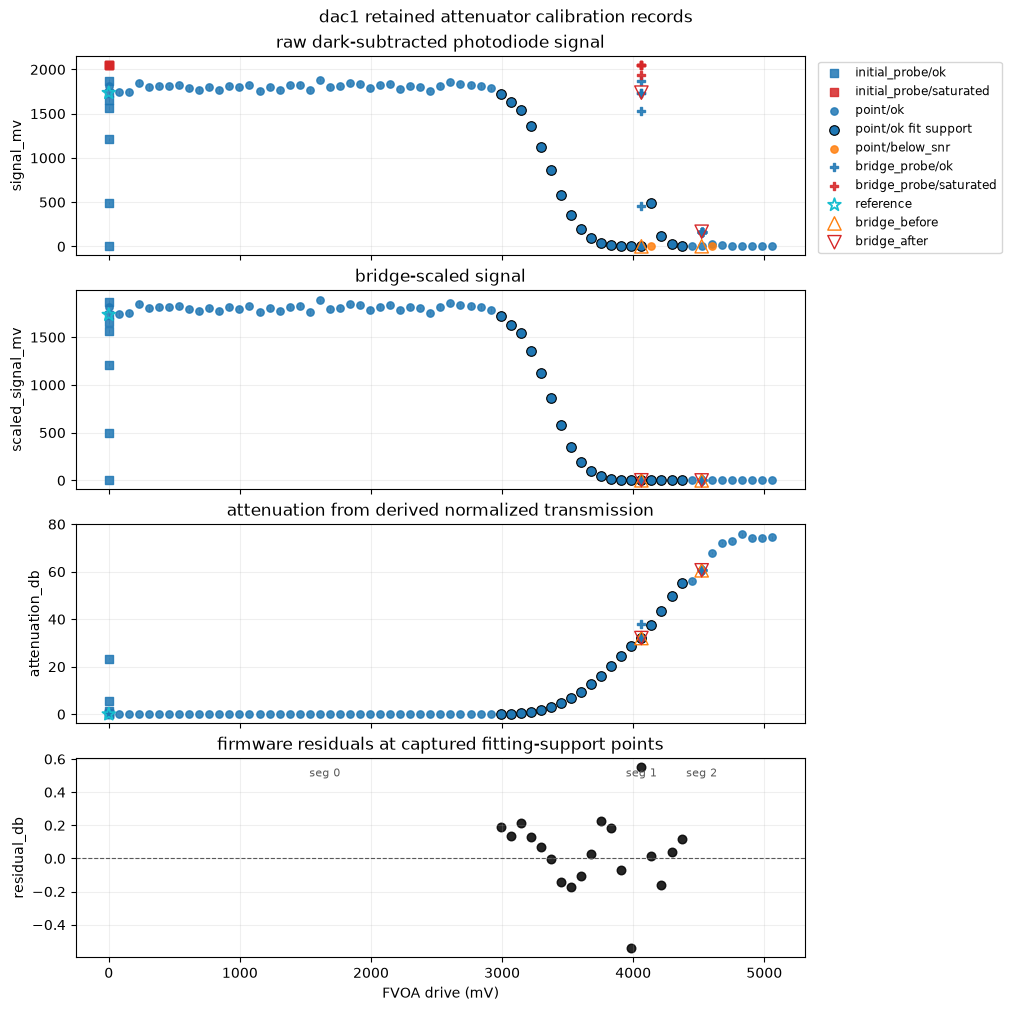

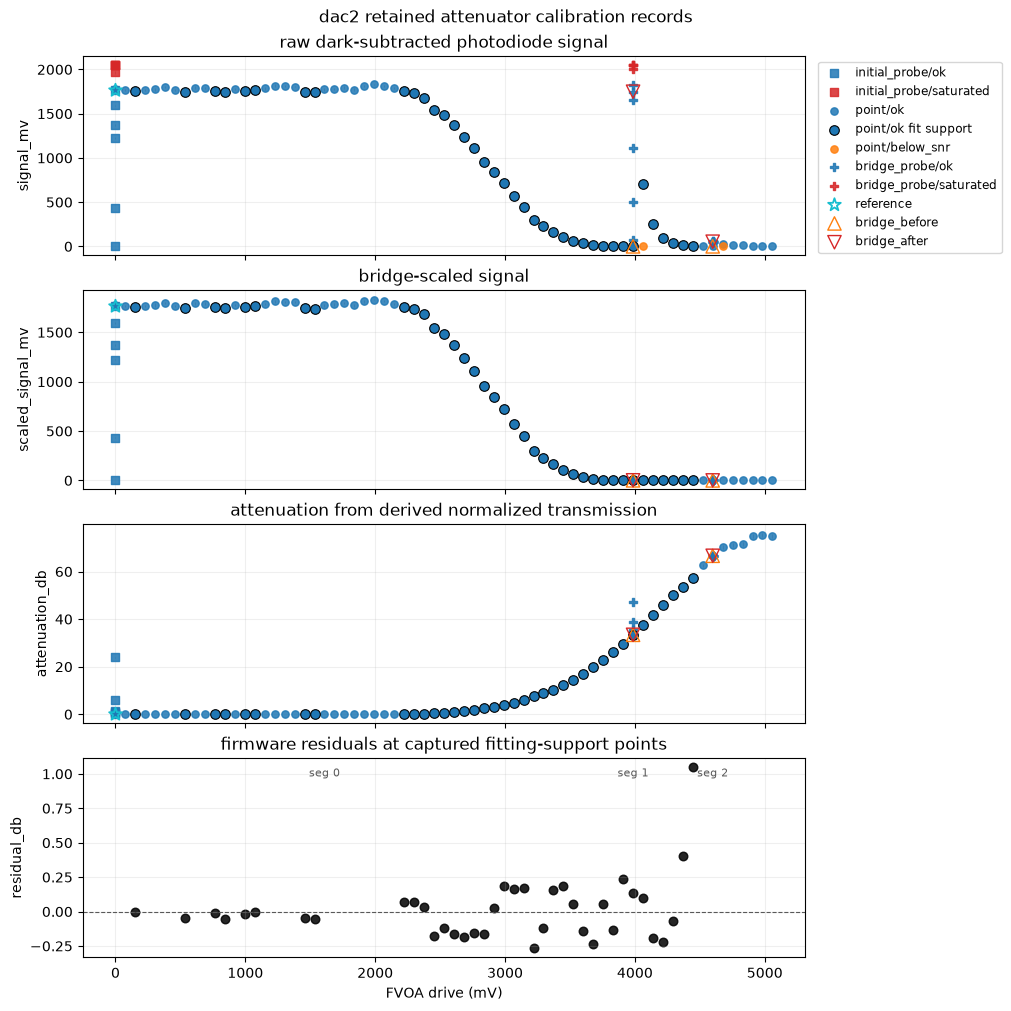

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=hk fixed_rms_mv=29.494 threshold_mv=10.000 uptime_ms=1578039
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=87.481 threshold_mv=10.000 uptime_ms=1579022


In [32]:
calibration.plot_physical("dac1");
calibration.plot_physical("dac2");

<a id="fits"></a>
## 2. Firmware fit and calibrated range

This section displays **the firmware fit saved with this capture**. The table and curve use
its returned coefficients and metrics; there is no host refit. The filename identifies the
source. Loading a capture does not establish which coefficients are currently on the PCB.

New firmware fits the existing erf + leakage-floor model and Chebyshev correction through the
first usable measurement **above 55 dB**. That extra point supports the boundary. It refits
with fewer leading correction terms when the final curve fails validation, with a base-only
fit as the last fallback. Six coefficient slots remain available.

`max_calibrated_db` bounds normal automatic operation. The correction joins continuously to
the rough continuation above it. Reported RMS, worst residual and correlation describe
measurements inside that limit; the above-limit support point is excluded from those metrics.
Firmware checks the final curve on a 1 mV grid, at fitting-support voltages and at the join.
Older captures retain the coefficients and metrics their firmware actually reported.

Run the imports and helper definitions in section 1, then this section; it needs no connection.
The chronological table shows initial probes and the first sweep reading, including both DAC
settings. In the raw plots, probes are squares and sweep points are circles; color indicates
classification. Multiple initial probes overlap at DUT voltage zero.

In [26]:
if CALIBRATION_FILE is None:
    raise ValueError("Set CALIBRATION_FILE to the saved .npz, or complete a calibration capture first.")
FIT_ARCHIVE = Path(CALIBRATION_FILE)
calibration, cal_context = load_calibration(FIT_ARCHIVE)
print("Firmware fit from this capture:", FIT_ARCHIVE.name)

Firmware fit from this capture: cal_1028y_20260921T184507_408674Z.npz


if calibration is not None and len(calibration.records):
    for physical in ("dac1", "dac2"):
        if np.any(calibration.records.physical == physical):
            calibration.plot_physical(physical, x_axis="sweep_mv")
            plt.show()
    calibration

In [27]:
initial_rows = []
for physical in ("dac1", "dac2"):
    records = calibration.physical(physical).records
    meta = calibration._physical_meta(physical) or {}
    sweeps = records[records.event == "point"]
    first_sweep = int(sweeps.record[0]) if len(sweeps) else None
    for record in records:
        if record.event != "initial_probe" and int(record.record) != first_sweep:
            continue
        initial_rows.append(dict(physical=physical, record=int(record.record),
            event=str(record.event), classification=str(record.classification),
            reference=bool(meta.get("reference_valid") and record.record == meta.get("reference_record")),
            dut_mv=record.sweep_mv, companion_mv=record.other_mv, laser_pct=record.laser_pct,
            net_mean_mv=record.signal_mv, raw_peak_mv=record.max_mv))
display(pd.DataFrame(initial_rows).round(3))
print("Search target: raw peak <1850 mV; PD linearity limit: 2000 mV; ADC full scale: 2048 mV.")

,physical,record,event,classification,reference,dut_mv,companion_mv,laser_pct,net_mean_mv,raw_peak_mv
0,dac1,0,initial_probe,ok,False,0.0,3300.000,100.0,7.851,7.438
1,dac1,1,initial_probe,saturated,False,0.0,1650.000,100.0,2049.141,2047.938
2,dac1,2,initial_probe,saturated,False,0.0,2475.000,100.0,2049.141,2047.938
3,dac1,3,initial_probe,ok,False,0.0,2887.500,100.0,491.538,536.500
4,dac1,4,initial_probe,saturated,False,0.0,2681.250,100.0,2049.141,2047.938
5,dac1,5,initial_probe,saturated,False,0.0,2784.375,100.0,2049.141,2047.938
6,dac1,6,initial_probe,ok,False,0.0,2835.938,100.0,1211.561,1300.688
7,dac1,7,initial_probe,ok,False,0.0,2810.156,100.0,1567.646,1640.938
8,dac1,8,initial_probe,ok,False,0.0,2797.266,100.0,1866.726,1994.500
9,dac1,9,initial_probe,ok,False,0.0,2803.711,100.0,1657.214,1762.938


Search target: raw peak <1850 mV; PD linearity limit: 2000 mV; ADC full scale: 2048 mV.


In [28]:
firmware_results, fit_rows = {}, []
fits = next((item["fits"] for item in calibration.meta if "fits" in item), {})
derived = calibration.derived()
for physical in ("dac1", "dac2"):
    fit = fits.get(physical)
    firmware = calibration._fit_coeff_for_physical(physical)
    if fit is None or firmware is None:
        fit_rows.append(dict(physical=physical, accepted=False, model="No valid captured fit"))
        continue
    gain = float(cal_context.get("coeff", {}).get(physical, {}).get("gain", hspcb.ATTENUATOR_DEFAULT_GAIN))
    firmware = (*firmware[:3], gain, firmware[4], firmware[5])
    points = derived[(derived.physical == physical) & derived.fit_candidate]
    support = np.asarray(points.included, dtype=bool)
    limit = fit.max_calibrated_db
    # Classify the boundary at firmware measured-dB precision (float32).
    # The reported firmware metrics remain authoritative.
    in_range = (support & (np.asarray(points.db, dtype=np.float32) <= np.float32(limit))
                if limit is not None else np.zeros(len(points), dtype=bool))
    terms = max((i+1 for i,c in enumerate(firmware[4]) if c != 0), default=0)
    model_name = f"base + {terms}-term Chebyshev" if terms else "base only"
    grid = np.arange(0, hspcb.ATTENUATOR_DRIVE_MAX_MV+1)
    curve = hspcb._atten_db_from_coeff(firmware, grid)
    finite = bool(np.all(np.isfinite(curve)))
    monotonic = finite and bool(np.all(np.diff(curve) >= -1e-5))
    nonnegative = finite and bool(np.min(curve) >= 0)
    fit_rows.append(dict(physical=physical, accepted=fit.accepted, model=model_name,
        fit_support_points=fit.points, measured_in_range=int(np.sum(in_range)),
        max_calibrated_db=limit, leakage_floor_db=fit.max_atten_db,
        firmware_rms_db=fit.rms_db, firmware_worst_db=fit.max_abs_db,
        firmware_correlation=fit.corr, monotonic_grid=monotonic, nonnegative_grid=nonnegative))
    firmware_results[physical] = dict(points=points, support=support, in_range=in_range,
        coefficients=firmware, limit=limit, model_name=model_name)
fit_table = pd.DataFrame(fit_rows).round(3)
display(fit_table.astype(object).where(pd.notna(fit_table), "—"))
print("RMS/worst/correlation are reported by the capture's firmware. Grid checks use 1 mV spacing.")

,physical,accepted,model,fit_support_points,measured_in_range,max_calibrated_db,leakage_floor_db,firmware_rms_db,firmware_worst_db,firmware_correlation,monotonic_grid,nonnegative_grid
0,dac1,True,base + 6-term Chebyshev,19,18,55.0,74.347,0.223,0.551,1.0,True,True
1,dac2,True,base + 6-term Chebyshev,38,37,55.0,75.062,0.151,0.401,1.0,True,True


RMS/worst/correlation are reported by the capture's firmware. Grid checks use 1 mV spacing.


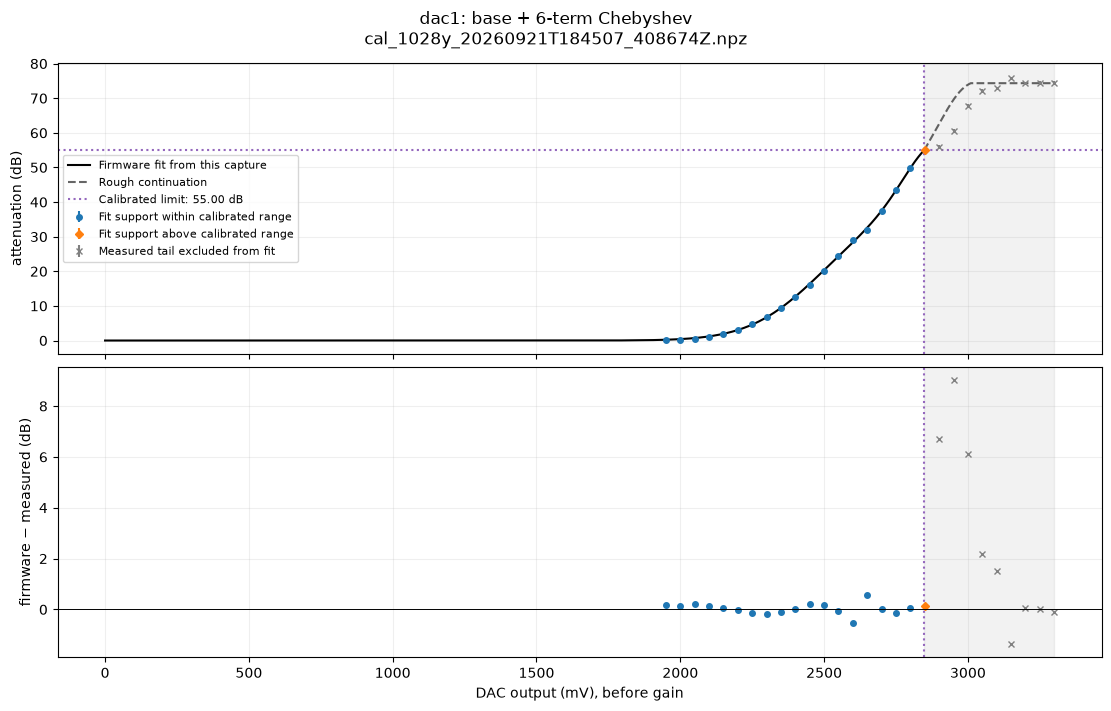

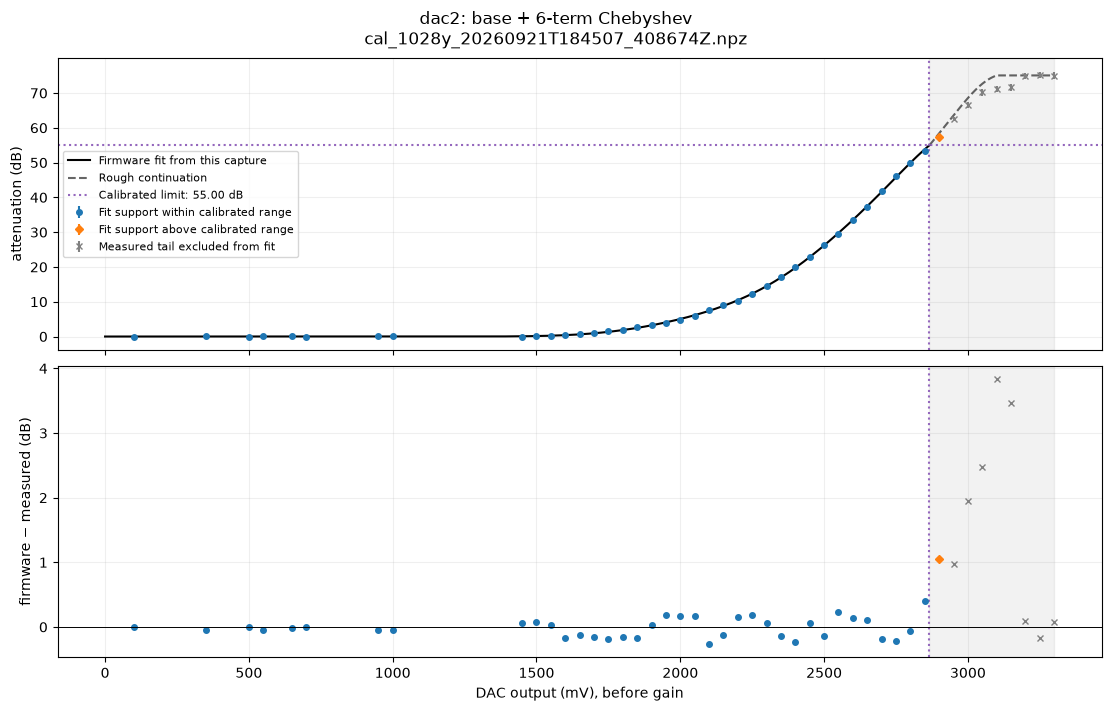

In [29]:
for physical, result in firmware_results.items():
    points, firmware = result["points"], result["coefficients"]
    support, in_range, limit = result["support"], result["in_range"], result["limit"]
    grid = np.arange(0, hspcb.ATTENUATOR_DRIVE_MAX_MV+1, dtype=float)
    curve = hspcb._atten_db_from_coeff(firmware, grid)
    boundary_mv = None
    if limit is not None:
        crossing = np.flatnonzero(curve >= limit)
        if len(crossing):
            k = int(crossing[0])
            boundary_mv = float(np.interp(limit, curve[max(0,k-1):k+1], grid[max(0,k-1):k+1]))
            grid = np.unique(np.r_[grid, boundary_mv])
            curve = hspcb._atten_db_from_coeff(firmware, grid)
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, layout="constrained")
    inside = grid <= boundary_mv if boundary_mv is not None else np.ones(len(grid), dtype=bool)
    axes[0].plot(grid[inside], curve[inside], color="black", label="Firmware fit from this capture")
    if boundary_mv is not None:
        outside = grid >= boundary_mv
        axes[0].plot(grid[outside], curve[outside], "--", color="black", alpha=.6, label="Rough continuation")
        axes[0].axhline(limit, color="tab:purple", ls=":", label=f"Calibrated limit: {limit:.2f} dB")
        for ax in axes:
            ax.axvline(boundary_mv, color="tab:purple", ls=":")
            ax.axvspan(boundary_mv, grid[-1], color="gray", alpha=.1)
    residual = hspcb._atten_db_from_coeff(firmware, points.sweep_mv)-points.db
    for mask, marker, color, label in [
        (in_range, "o", "tab:blue", "Fit support within calibrated range"),
        (support & ~in_range, "D", "tab:orange", "Fit support above calibrated range"),
        (~support, "x", "gray", "Measured tail excluded from fit")]:
        if not np.any(mask):
            continue
        axes[0].errorbar(points.sweep_mv[mask], points.db[mask], yerr=points.db_err[mask],
                         fmt=marker, color=color, markersize=4, label=label)
        axes[1].plot(points.sweep_mv[mask], residual[mask], marker, color=color, markersize=4)
    axes[0].set(ylabel="attenuation (dB)")
    axes[0].legend(fontsize=8)
    axes[1].axhline(0, color="black", lw=.7)
    axes[1].set(xlabel="DAC output (mV), before gain", ylabel="firmware − measured (dB)")
    fig.suptitle(f"{physical}: {result['model_name']}\n{FIT_ARCHIVE.name}")
    plt.show()

**Interpret the captured result directly.** A base-only result means no correction is active;
reduced-order results have zero high-order coefficient slots. `accepted` reports firmware's
fit decision, not an absolute accuracy guarantee. Compare its residuals with the plotted data.
The plot boundary is the corrected curve's calibrated limit, located to the 1 mV plotting grid.
A measured in-range point with an out-of-range prediction still contributes its full error.

`leakage_floor_db` is the existing `max_atten_db` parameter. Automatic operation is bounded by
`max_calibrated_db`; manual dB, linear and voltage commands retain access to the rough tail.
The noise acquisition below uses the installed firmware coefficients.

<a id="acquire"></a>
## 3. Acquire fixed-setting noise data

The default program is a dark trace followed by **25+35 → 25+25 → 25+35**, with one fixed laser
level across all illuminated steps. `autolevel=False` is explicit. The alternate program redistributes
attenuation at fixed totals to change each FVOA's sensitivity without deliberately changing detector
brightness. Check the actual means: calibration errors can make equal programmed totals unequal.

An optional detector-chain control is a separate run at the **same ADC mean** with the FVOAs near
open and enough additional static attenuation to compensate. Arrange that attenuation with the laser
off and record the new setup before approving another run. This removes most FVOA slope sensitivity
without changing detector brightness; it is not an automatic step in either program.

Each record keeps its acquisition timestamp, raw/net ADC, source estimates, firmware uncertainties,
and route factors. The sidecar JSON includes command pairs, confirmed DAC positions, coefficients,
dark, response settings, temperatures, firmware ID, setup notes, and completion/error state.
Runs save after each step and again during cleanup. Laser-off is attempted on exceptions and Ctrl-C.
A kernel crash cannot run Python cleanup; a finite firmware laser auto-off is also requested.

This cell sets the selected laser to zero first and recaptures its channel's dark (RAM only).
The physical setup must be dark then; unrelated light is not controlled here. The `measure_throughput`
command still selects logical MEMS routes, which are optically bypassed in this experiment. It does
not adjust the manually set laser or DACs. Recorded route factors are audited offline below;
this notebook does not silently replace them on the PCB.

In [30]:
np.linspace(50-1.75, 60, num=5)

array([48.25  , 51.1875, 54.125 , 57.0625, 60.    ])

In [33]:
PROGRAM = "atten_scan" #repeat_levels" Or "redistribute".
STEP_SECONDS = 35.0
DARK_SECONDS = 15.0
SETTLE_SECONDS = 1.0         # Retain these raw samples; omit them from stationary summaries.
LASER_FRACTION = 0.1         # Set an approved fixed level, 0 < value <= 1; never inferred from old data.
PROGRAMS = {
    "repeat_levels": [("dim A", 25, 35), ("bright B", 25, 25), ("dim A repeat", 25, 35)],
    "redistribute": [("50 ref", 25, 25), ("50 left", 20, 30), ("50 ref repeat", 25, 25),
                     ("50 right", 30, 20), ("60 ref", 25, 35), ("60 balanced", 30, 30),
                     ("60 reversed", 35, 25), ("60 ref repeat", 25, 35)],
    "atten_scan": [(f"{db:2.1f} a1", float(db), 0) for db in np.linspace(50, 60, num=5)]+
                  [(f"{db:2.1f} a2", 0, float(db)) for db in np.linspace(50, 60, num=5)],
}


def write_noise_capture(path, frames, metadata):
    """Write raw samples before downstream statistics; JSON remains ordinary inspectable metadata."""
    data = (pd.concat(frames.values(), ignore_index=True) if frames else
            pd.DataFrame(columns=[*hspcb.THROUGHPUT_DTYPE.names, "step_index", "step_label"]))
    data.to_csv(path, index=False)
    path.with_suffix(".json").write_text(json.dumps(json_value(metadata), indent=2, allow_nan=False))


def acquire_noise_sequence(client, program):
    """Own this finite bench sequence; always attempt laser-off, stream stop, and partial save."""
    if not NOISE_LASER_APPROVED or LASER_FRACTION is None or not 0 < LASER_FRACTION <= 1:
        raise RuntimeError("Approve the illuminated sequence and set its fixed LASER_FRACTION first.")
    if STEP_SECONDS < 10 or DARK_SECONDS < 10 or SETTLE_SECONDS < 0:
        raise ValueError("Use at least 10 seconds per trace and a nonnegative settling exclusion.")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
    path = DATA_DIR / f"noise_{LASER}_{stamp}.csv"
    metadata = dict(context=setup_snapshot(client), program=program, command_model="installed",
        laser_fraction=LASER_FRACTION,
        settle_seconds=SETTLE_SECONDS, steps=[], complete=False)
    frames, monitor, step_index = {}, None, -1
    try:
        client.stop_throughput(CHANNEL)
        client.laser(LASER, stop=True)
        client.pd(CHANNEL)  # Explicit detector preparation, also needed after expiry.
        dark = client.pd_dark(CHANNEL, duration_ms=2000, persist=False)
        deadline = time.monotonic() + 15
        while dark.pending:
            if time.monotonic() > deadline:
                raise TimeoutError("Dark acquisition did not complete.")
            time.sleep(.25)
            dark = client.pd_dark(CHANNEL)
        metadata["dark_before"] = json_value(dark)
        steps = [("dark", None, None)] + list(program)
        for step_index, (label, db1, db2) in enumerate(steps):
            if db1 is not None:
                state = client.atten(LASER, value1_db=float(db1), value2_db=float(db2))
                if step_index == 1:
                    remaining_s = math.ceil(len(program) * (STEP_SECONDS + SETTLE_SECONDS + 15) + 60)
                    client.laser(LASER, value=LASER_FRACTION, autooff_s=remaining_s)
            else:
                state = client.atten(LASER)
            duration = (DARK_SECONDS if db1 is None else STEP_SECONDS) + SETTLE_SECONDS
            metadata["steps"].append(dict(index=step_index, label=label, command_db=[db1, db2],
                state=json_value(state), start_utc=datetime.now(timezone.utc).isoformat()))
            monitor = client.measure_throughput(LASER, channel=CHANNEL, output=OUTPUT, fiber=FIBER,
                autolevel=False, collect=True, off_in_s=math.ceil(duration + 15),
                max_samples=math.ceil((duration + 15) * 25))
            start, last_new, next_notice = time.monotonic(), time.monotonic(), 0.0
            previous_count = 0
            while time.monotonic() - start < duration:
                time.sleep(.25)
                rec = monitor.to_recarray()
                if len(rec) > previous_count:
                    previous_count, last_new = len(rec), time.monotonic()
                if time.monotonic() - last_new > 5:
                    raise TimeoutError("No fresh throughput records for five seconds.")
                if len(rec) and (np.any(rec.pd_mv >= hspcb.PD_ADC_USABLE_MV) or np.any(rec.autolevel)):
                    raise RuntimeError("Overrange or unexpected autolevel; raw samples retained.")
                if time.monotonic() - start >= next_notice:
                    print(f"{label}: {len(rec)} samples; {time.monotonic()-start:.0f}/{duration:.0f} s", flush=True)
                    next_notice += 15
            monitor.stop()
            frame = monitor.to_dataframe()
            frame["step_index"], frame["step_label"] = step_index, label
            frames[step_index] = frame
            monitor = None
            write_noise_capture(path, frames, metadata)
        metadata["complete"] = True
        metadata["end_context"] = setup_snapshot(client)
    except BaseException as exc:
        metadata["error"] = repr(exc)
        raise
    finally:
        metadata["laser_off_confirmed"] = False
        metadata["stream_stop_confirmed"] = False
        try:
            client.laser(LASER, stop=True)
            metadata["laser_off_confirmed"] = True
        finally:
            try:
                if monitor is not None:
                    monitor.stop()
                else:
                    client.stop_throughput(CHANNEL)
                metadata["stream_stop_confirmed"] = True
            finally:
                if monitor is not None:
                    frame = monitor.to_dataframe()
                    frame["step_index"] = step_index
                    frame["step_label"] = metadata["steps"][-1]["label"]
                    frames[step_index] = frame
                write_noise_capture(path, frames, metadata)
                print("Saved raw/partial capture:", path)
    return path

In [34]:
if RUN_NOISE_SEQUENCE:
    if pcb is None:
        raise RuntimeError("Connect first.")
    last_noise_csv = acquire_noise_sequence(pcb, PROGRAMS[PROGRAM])
else:
    display(pd.DataFrame(PROGRAMS[PROGRAM], columns=["step", "dac1_db", "dac2_db"]))
    print("Noise acquisition disabled. No laser or attenuator commands issued.")

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=614.119 threshold_mv=10.000 uptime_ms=2334172


dark: 5 samples; 0/16 s
dark: 306 samples; 15/16 s
50.0 a1: 5 samples; 0/36 s
50.0 a1: 305 samples; 15/36 s
50.0 a1: 606 samples; 30/36 s
52.5 a1: 6 samples; 0/36 s
52.5 a1: 305 samples; 15/36 s
52.5 a1: 601 samples; 30/36 s


PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=14.295 threshold_mv=10.000 uptime_ms=2426422


55.0 a1: 5 samples; 0/36 s
55.0 a1: 305 samples; 15/36 s
55.0 a1: 604 samples; 30/36 s
57.5 a1: 5 samples; 0/36 s
57.5 a1: 304 samples; 15/36 s
57.5 a1: 606 samples; 30/36 s


PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=14.877 threshold_mv=10.000 uptime_ms=2499373


...

50.0 a2: 602 samples; 30/36 s
52.5 a2: 5 samples; 0/36 s
52.5 a2: 305 samples; 15/36 s
52.5 a2: 602 samples; 30/36 s
55.0 a2: 6 samples; 0/36 s
55.0 a2: 305 samples; 15/36 s
55.0 a2: 602 samples; 30/36 s


PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=13.054 threshold_mv=10.000 uptime_ms=2645822


57.5 a2: 6 samples; 0/36 s
57.5 a2: 305 samples; 15/36 s
57.5 a2: 602 samples; 30/36 s
60.0 a2: 5 samples; 0/36 s
60.0 a2: 304 samples; 15/36 s
60.0 a2: 602 samples; 30/36 s


PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=10.701 threshold_mv=10.000 uptime_ms=2719672


Saved raw/partial capture: /Users/jibailey/src/hispec-zephyr-mlang/hispec-tib/tools/atten_noise_data/noise_1028y_20260921T190518_174606Z.csv


### Stop selected laser / measurement

Run this cell manually if needed. It attempts the explicit laser-off even if stopping the stream fails.
It does not power down the laser bank or TECs. After an interrupted run, load the printed partial
CSV path below; it is valid evidence of the interruption, not a completed sequence.

In [35]:
STOP_NOW = 0
if STOP_NOW and pcb is not None:
    try:
        pcb.stop_throughput(CHANNEL)
    finally:
        pcb.laser(LASER, stop=True)

<a id="noise"></a>
## 4. Load a capture and audit its assumptions

The default historical CSV is a real **autolevel** capture, not the fixed-setting data quoted above.
It is useful for route/error arithmetic and timing. Stationary-noise cells exclude autolevel records.
Select a new noise CSV to evaluate the fixed-setting experiments.

Use signed net ADC values for noise analysis. Do not fit the zero-clipped optical-power column near
darkness. Invalid and overrange samples, duplicate/reversed timestamps, gaps, channel/source changes,
DAC attenuation steps, and current steps break stationary segments; no interpolation joins them.

In [36]:
source_csv = Path(NOISE_CSV or last_noise_csv or HISTORICAL_CSV)
noise_meta = {}
data = pd.DataFrame()
if source_csv.is_file():
    data = pd.read_csv(source_csv)
    sidecar = source_csv.with_suffix(".json")
    if sidecar.is_file():
        noise_meta = json.loads(sidecar.read_text())
    display(pd.DataFrame([dict(file=source_csv.name, records=len(data),
        columns=len(data.columns), metadata=bool(noise_meta), complete=noise_meta.get("complete", "historical/unknown"))]))
    if "pd_settings" in noise_meta.get("context", {}):
        EFFECTIVE_GAIN_V_PER_A = float(noise_meta["context"]["pd_settings"]["transimpedance_v_per_a"])
    data["laser"] = data["laser"].fillna("")
else:
    print("No capture at", source_csv, "— acquire or select a file.")

,file,records,columns,metadata,complete
0,noise_1028y_20260921T190518_174606Z.csv,7575,28,True,True


In [37]:
def stationary_segments(frame, settle_s=SETTLE_SECONDS, minimum_s=10.0):
    """Return separate continuous fixed-setting intervals; never close gaps by dropping bad rows."""
    required = {"t_ms", "pd_net_mv", "pd_mv", "autolevel", "atten_db", "laser_current_ma", "channel", "laser"}
    if not required <= set(frame):
        raise ValueError(f"Missing current stream fields: {sorted(required-set(frame))}")
    if len(frame) < 3:
        return []
    dt = frame.t_ms.diff() / 1000.0
    nominal = float(dt[dt > 0].median())
    valid = np.isfinite(frame.pd_net_mv) & np.isfinite(frame.pd_mv) & (frame.pd_mv < hspcb.PD_ADC_USABLE_MV)
    valid &= frame.autolevel.eq(False) & np.isfinite(frame.atten_db) & np.isfinite(frame.laser_current_ma)
    if "flags" in frame:
        valid &= ~frame["flags"].astype(str).str.contains("overrange", regex=False)
    boundary = (dt <= 0) | (dt > 1.5 * nominal) | ~valid | ~valid.shift(fill_value=False)
    boundary |= frame.channel.ne(frame.channel.shift()) | frame.laser.ne(frame.laser.shift())
    boundary |= frame.atten_db.diff().abs().gt(.02) | frame.laser_current_ma.diff().abs().gt(.2)
    if "step_index" in frame:
        boundary |= frame.step_index.ne(frame.step_index.shift())
    result = []
    for _, part in frame.groupby(boundary.cumsum(), sort=False):
        if not valid.loc[part.index].all():
            continue
        elapsed = (part.t_ms - part.t_ms.iloc[0]) / 1000.0
        part = part.loc[elapsed >= settle_s].copy()
        if len(part) < 3 or (part.t_ms.iloc[-1] - part.t_ms.iloc[0]) / 1000 < minimum_s:
            continue
        result.append(part.reset_index(drop=True))
    return result


def time_statistics(part):
    y = part.pd_net_mv.to_numpy(float)
    dt = np.diff(part.t_ms.to_numpy(float)) / 1000
    rms = float(np.std(y, ddof=1))
    centered = y - y.mean()
    corr = signal.correlate(centered, centered, mode="full", method="fft")[len(y)-1:]
    corr = corr / np.arange(len(y), 0, -1)
    corr = corr / corr[0] if corr[0] > 0 else np.full_like(corr, np.nan)
    fs = 1 / np.median(dt)
    nperseg = min(1024, max(32, len(y)//4))
    f, psd = signal.welch(y, fs=fs, nperseg=nperseg, detrend="constant")
    blocks = []
    for seconds in (.05, .1, .25, .5, 1, 2, 5, 10, 20, 30):
        m = max(1, round(seconds * fs))
        n = len(y) // m
        if n < 8:
            continue
        means = y[:n*m].reshape(n, m).mean(axis=1)
        block_rms = float(np.std(means, ddof=1))
        blocks.append(dict(tau_s=m/fs, blocks=n, rms_mean_mv=block_rms,
            iid_rms_mean_mv=rms/np.sqrt(m), empirical_se_mv=block_rms/np.sqrt(n),
            adjacent_block_corr=float(np.corrcoef(means[:-1], means[1:])[0, 1]) if block_rms > 0 else np.nan,
            allan_mv=float(np.sqrt(.5*np.mean(np.diff(means)**2)))))
    total_power = np.trapezoid(psd, f)
    return dict(mean_mv=float(y.mean()), rms_mv=rms, detrended_rms_mv=float(np.std(signal.detrend(y), ddof=1)),
        relative_rms=rms/abs(y.mean()) if abs(y.mean()) > 3*rms else np.nan,
        adjacent_corr=float(corr[1]), fs_hz=fs, max_gap_ms=float(max(dt)*1000),
        timing_jitter_rms_ms=float(np.std(dt)*1000),
        sub3_fraction=float(np.trapezoid(psd[f <= 3], f[f <= 3])/total_power) if total_power > 0 else np.nan,
        acf=corr, frequencies=f, psd=psd, blocks=pd.DataFrame(blocks))


segments, statistics = [], []
if not data.empty:
    dt_ms = data.t_ms.diff()
    display(pd.DataFrame([dict(records=len(data), median_dt_ms=dt_ms[dt_ms>0].median(),
        duplicate_or_reversed=int((dt_ms<=0).sum()), gaps_over_75ms=int((dt_ms>75).sum()),
        raw_overrange=int((data.pd_mv>=hspcb.PD_ADC_USABLE_MV).sum()),
        autolevel_records=int(data.autolevel.eq(True).sum()),
        raw_code_max_error_mv=float(np.nanmax(abs(data.pd_mv-data.pd_raw*.0625))) if "pd_raw" in data else np.nan)]))
    segments = stationary_segments(data)
    statistics = [time_statistics(part) for part in segments]
    summary = pd.DataFrame([dict(interval=i, label=part.step_label.iloc[0] if "step_label" in part else "fixed interval",
        count=len(part), atten_db=part.atten_db.median(), current_ma=part.laser_current_ma.median(),
        **{k: v for k,v in stats.items() if np.isscalar(v)})
        for i,(part,stats) in enumerate(zip(segments, statistics))])
    display(summary)
    if not segments:
        print("No eligible fixed-setting intervals. Autolevel captures are not stationary noise measurements.")

,records,median_dt_ms,duplicate_or_reversed,gaps_over_75ms,raw_overrange,autolevel_records,raw_code_max_error_mv
0,7575,50.0,0,10,0,0,0.0


,interval,label,count,atten_db,current_ma,mean_mv,rms_mv,detrended_rms_mv,relative_rms,adjacent_corr,fs_hz,max_gap_ms,timing_jitter_rms_ms,sub3_fraction
0,0,dark,302,55.019821,0.0,-55.844081,0.360834,0.320719,0.006461,0.262262,20.0,50.0,1.387779e-14,0.316492
1,1,50.0 a1,705,49.989205,38.1,123.322961,12.559331,11.845391,0.101841,0.939609,20.0,50.0,6.938894e-15,0.739245
2,2,52.5 a1,705,52.457633,38.1,43.466046,2.203158,2.130408,0.050687,0.438791,20.0,50.0,6.938894e-15,0.518663
3,3,55.0 a1,704,54.987222,38.1,79.689702,3.269862,3.243009,0.041032,0.353576,20.0,50.0,1.387779e-14,0.453516
4,4,57.5 a1,704,57.467066,38.1,18.884393,2.441539,2.028025,0.129289,0.603092,20.0,50.0,1.387779e-14,0.527149
5,5,60.0 a1,706,59.982385,38.1,-30.912075,0.762470,0.685119,0.024666,0.428209,20.0,50.0,0.000000e+00,0.462182
6,6,50.0 a2,705,49.991157,38.1,302.649202,34.039133,26.910063,0.112471,0.793591,20.0,50.0,6.938894e-15,0.560164
7,7,52.5 a2,706,52.483225,38.1,123.877674,10.849071,10.816086,0.087579,0.476094,20.0,50.0,0.000000e+00,0.582540
8,8,55.0 a2,707,55.019821,38.1,41.324470,6.183747,6.183666,0.149639,0.363300,20.0,50.0,6.938894e-15,0.486250
9,9,57.5 a2,705,57.467156,38.1,3.585106,4.167764,4.155504,NaN,0.462434,20.0,50.0,6.938894e-15,0.544730


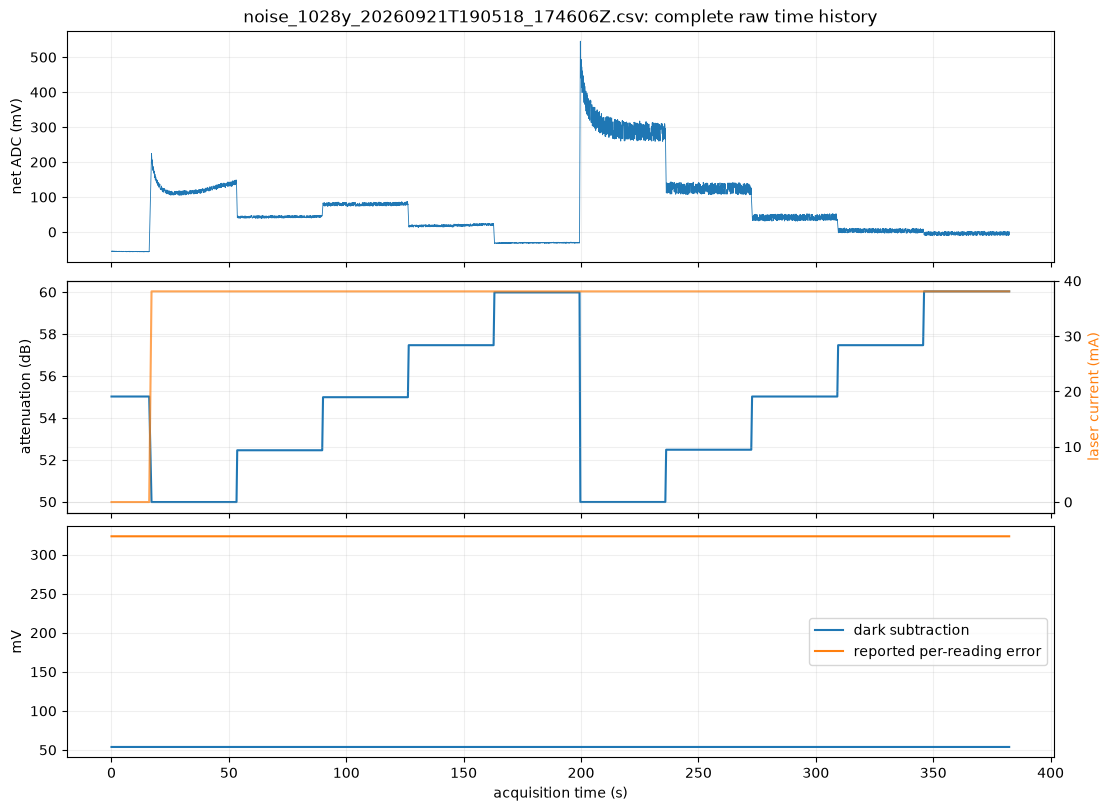

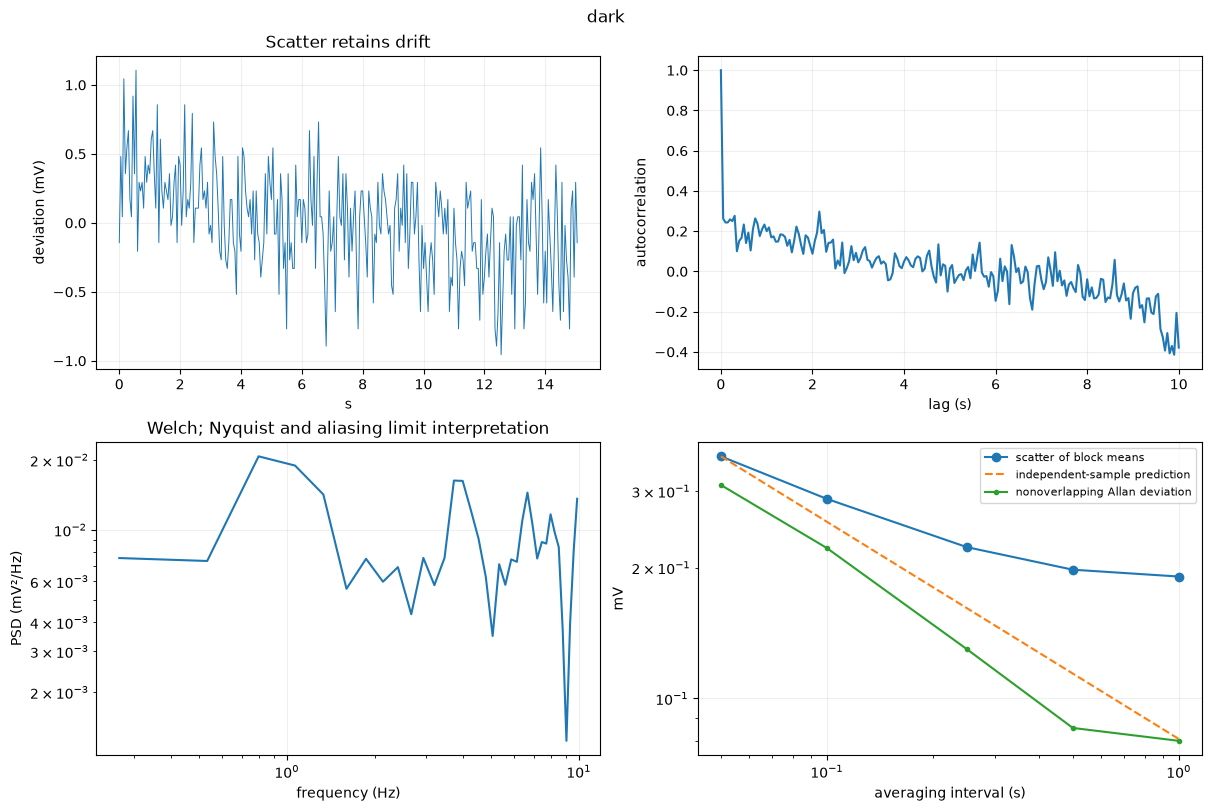

,tau_s,blocks,rms_mean_mv,iid_rms_mean_mv,empirical_se_mv,adjacent_block_corr,allan_mv
0,0.05,302,0.360834,0.360834,0.020764,0.261530,0.309998
1,0.10,151,0.288004,0.255148,0.023437,0.405365,0.221934
2,0.25,60,0.222994,0.161370,0.028788,0.650761,0.129843
3,0.50,30,0.197865,0.114106,0.036125,0.799381,0.085534
4,1.00,15,0.190832,0.080685,0.049272,0.818388,0.079891


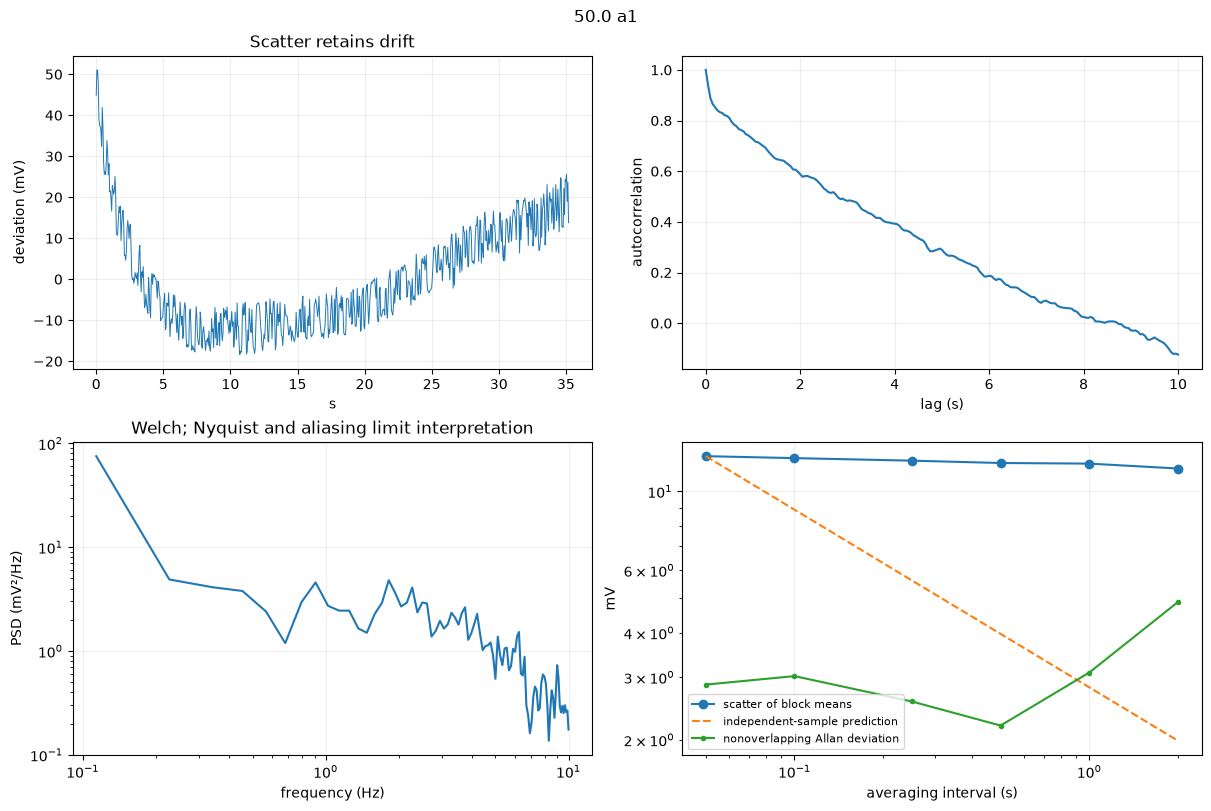

,tau_s,blocks,rms_mean_mv,iid_rms_mean_mv,empirical_se_mv,adjacent_block_corr,allan_mv
0,0.05,705,12.559331,12.559331,0.473012,0.947722,2.858357
1,0.10,352,12.401756,8.880788,0.661016,0.939296,3.020243
2,0.25,141,12.199027,5.616704,1.027343,0.953963,2.562255
3,0.50,70,12.016631,3.971609,1.436262,0.966477,2.192216
4,1.00,35,11.968328,2.808352,2.023017,0.927657,3.091060
5,2.00,17,11.593907,1.985805,2.811935,0.778895,4.883508


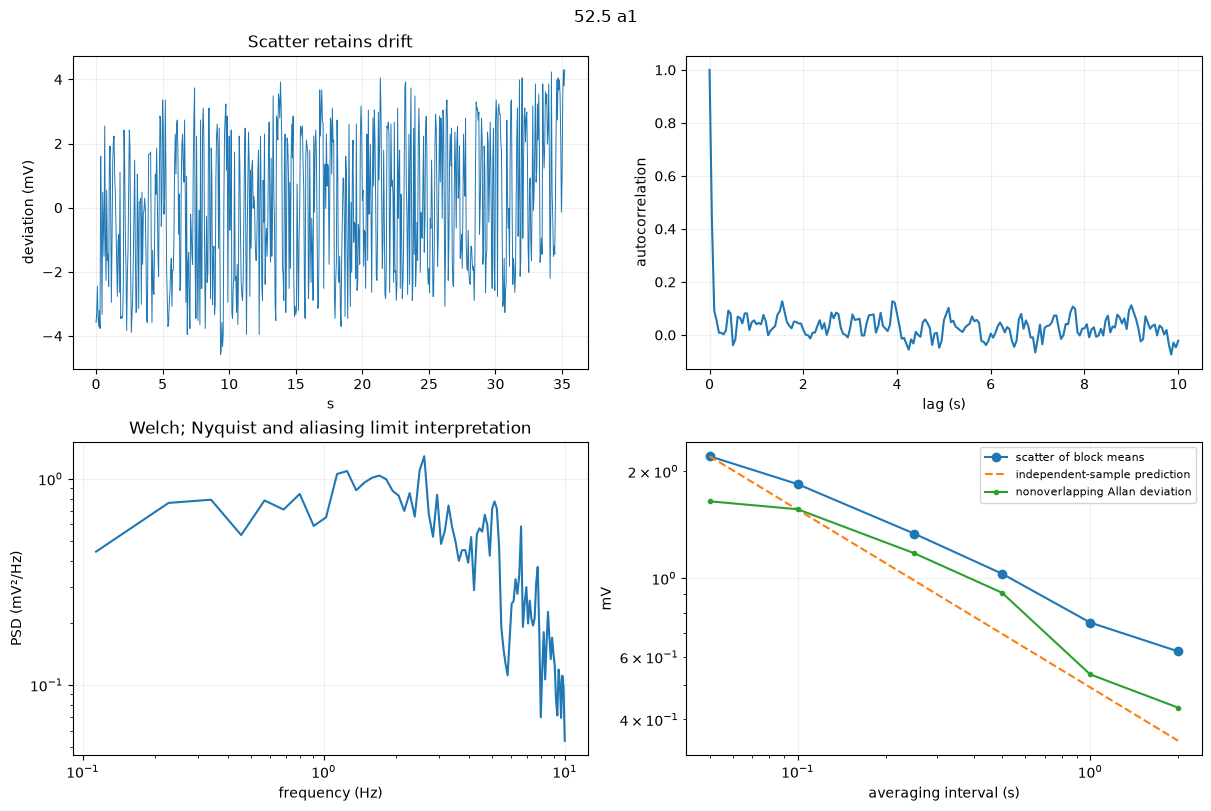

,tau_s,blocks,rms_mean_mv,iid_rms_mean_mv,empirical_se_mv,adjacent_block_corr,allan_mv
0,0.05,705,2.203158,2.203158,0.082976,0.440192,1.644650
1,0.10,352,1.838227,1.557868,0.097978,0.269314,1.562034
2,0.25,141,1.334441,0.985282,0.112380,0.188725,1.175271
3,0.50,70,1.028634,0.696700,0.122945,0.140013,0.909103
4,1.00,35,0.749584,0.492641,0.126703,0.420248,0.535708
5,2.00,17,0.621761,0.348350,0.150799,0.376735,0.431770


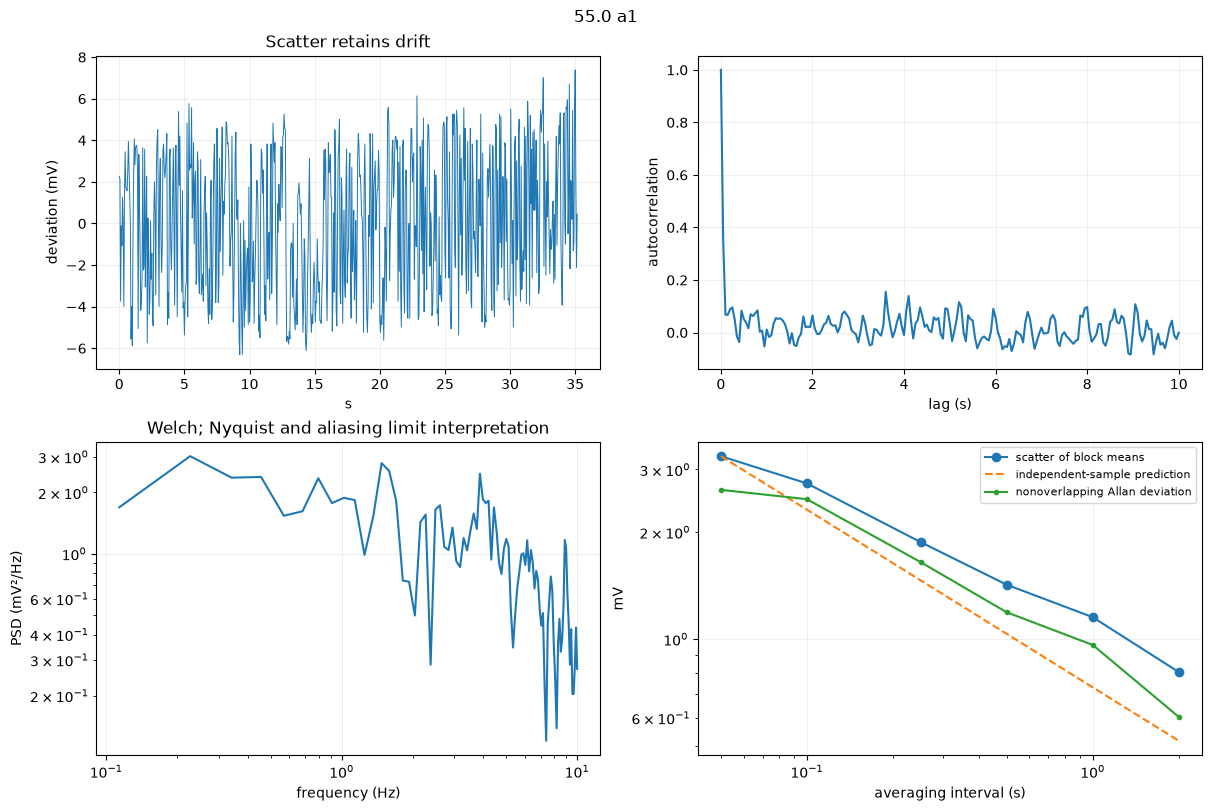

,tau_s,blocks,rms_mean_mv,iid_rms_mean_mv,empirical_se_mv,adjacent_block_corr,allan_mv
0,0.05,704,3.269862,3.269862,0.123238,0.353198,2.629289
1,0.10,352,2.740787,2.312141,0.146084,0.183960,2.474594
2,0.25,140,1.873366,1.462327,0.158328,0.225752,1.645675
3,0.50,70,1.421754,1.034021,0.169932,0.291292,1.189176
4,1.00,35,1.151871,0.731163,0.194702,0.268439,0.962188
5,2.00,17,0.807120,0.517011,0.195755,0.386171,0.603614


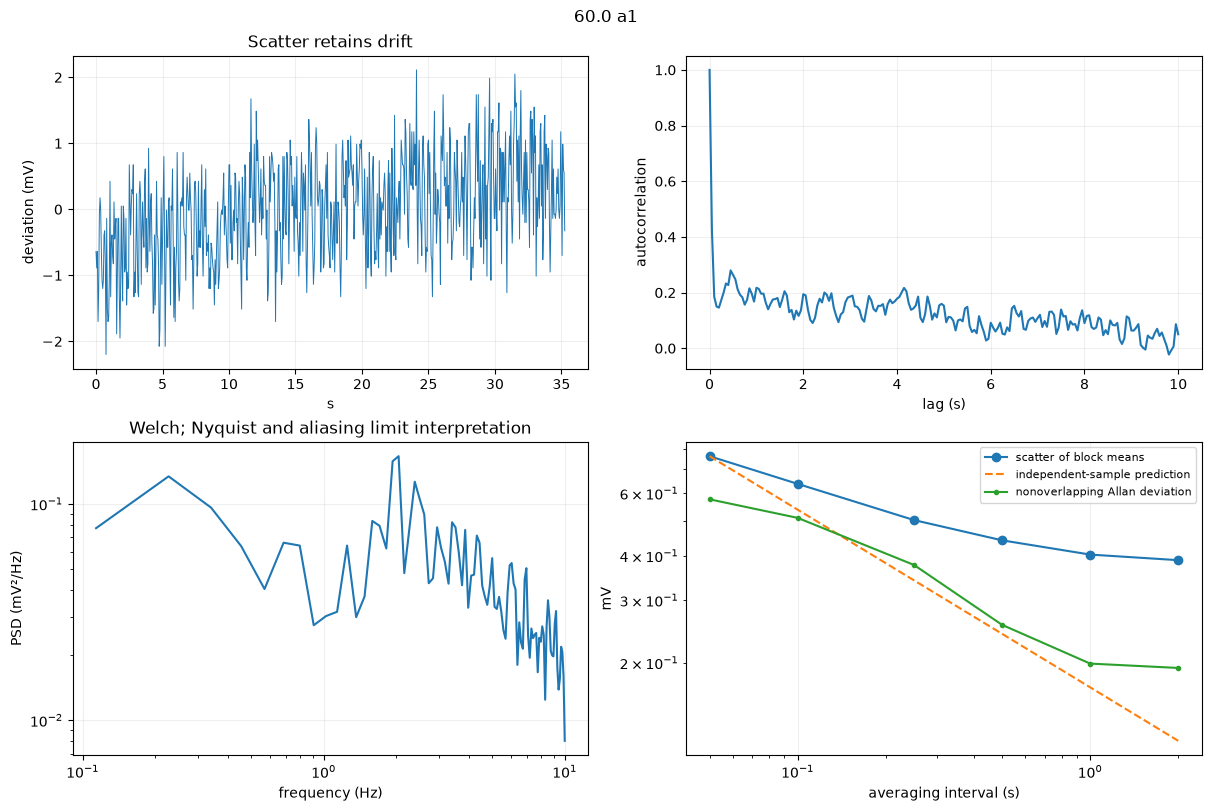

,tau_s,blocks,rms_mean_mv,iid_rms_mean_mv,empirical_se_mv,adjacent_block_corr,allan_mv
0,0.05,706,0.762470,0.762470,0.028696,0.427870,0.576546
1,0.10,353,0.637281,0.539147,0.033919,0.355112,0.511237
2,0.25,141,0.503941,0.340987,0.042440,0.431807,0.376764
3,0.50,70,0.441978,0.241114,0.052826,0.659837,0.255563
4,1.00,35,0.402997,0.170493,0.068119,0.741807,0.198847
5,2.00,17,0.388672,0.120557,0.094267,0.726332,0.193305


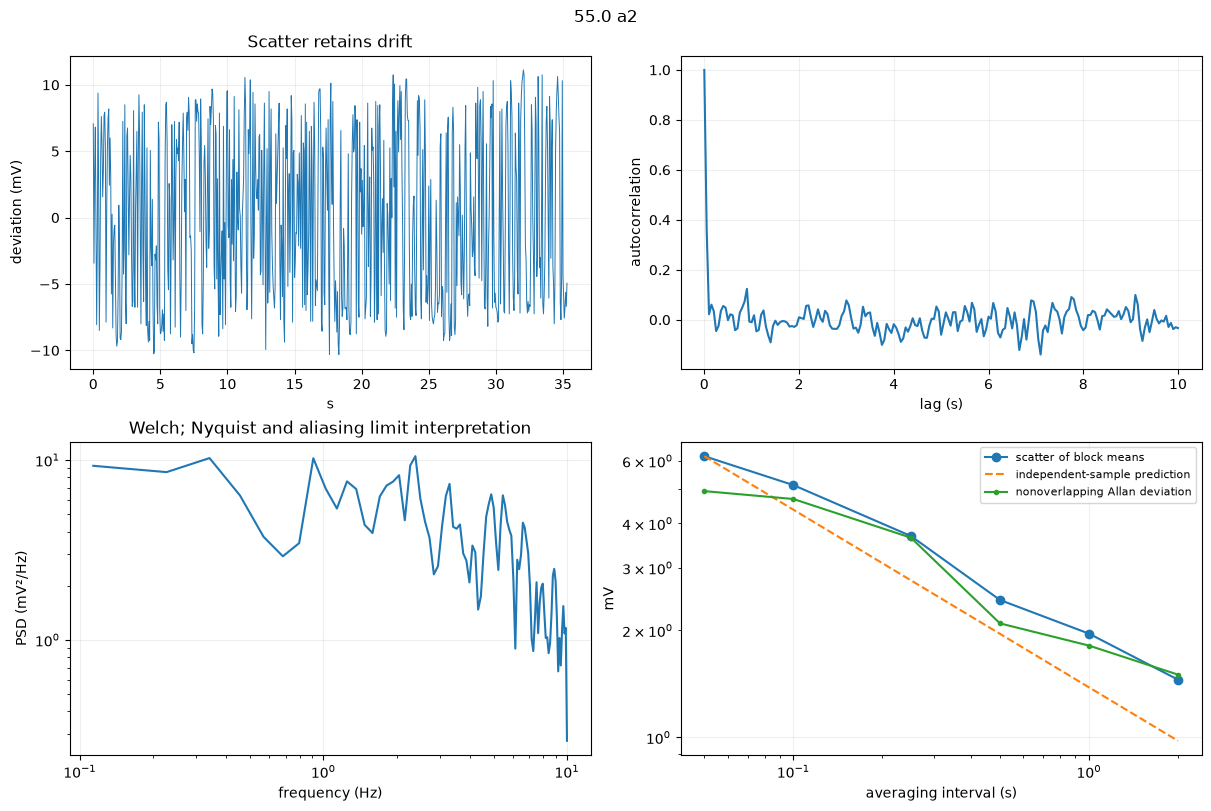

,tau_s,blocks,rms_mean_mv,iid_rms_mean_mv,empirical_se_mv,adjacent_block_corr,allan_mv
0,0.05,707,6.183747,6.183747,0.232564,0.363289,4.930886
1,0.10,353,5.128097,4.372569,0.272941,0.163235,4.685704
2,0.25,141,3.685127,2.765456,0.310344,0.009851,3.645387
3,0.50,70,2.435388,1.955472,0.291085,0.244651,2.092599
4,1.00,35,1.958205,1.382728,0.330997,0.107887,1.812142
5,2.00,17,1.453244,0.977736,0.352463,-0.072405,1.501316


PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=33.712 threshold_mv=10.000 uptime_ms=2935672
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=hk fixed_rms_mv=11.103 threshold_mv=10.000 uptime_ms=2936089


In [38]:
if not data.empty:
    t = (data.t_ms-data.t_ms.iloc[0])/1000
    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(11, 8), layout="constrained")
    axes[0].plot(t, data.pd_net_mv, lw=.6)
    axes[0].set(ylabel="net ADC (mV)", title=f"{source_csv.name}: complete raw time history")
    axes[1].plot(t, data.atten_db, label="reported total attenuation")
    axes[1].set_ylabel("attenuation (dB)")
    right = axes[1].twinx()
    right.plot(t, data.laser_current_ma, color="tab:orange", alpha=.7)
    right.set_ylabel("laser current (mA)", color="tab:orange")
    axes[2].plot(t, data.pd_mv-data.pd_net_mv, label="dark subtraction")
    if "pd_net_err_mv" in data:
        axes[2].plot(t, data.pd_net_err_mv, label="reported per-reading error")
    axes[2].set(xlabel="acquisition time (s)", ylabel="mV")
    axes[2].legend()
    plt.show()

for INTERVAL in [0,1,2,3, 5,8]:
#INTERVAL = 0  # Select from the summary; never concatenate separated intervals for spectra.
    if statistics:
        stats, part = statistics[INTERVAL], segments[INTERVAL]
        if stats["timing_jitter_rms_ms"] > .05*1000/stats["fs_hz"]:
            print("Timing jitter exceeds 5% of cadence; FFT frequency estimates are approximate.")
        fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
        t = (part.t_ms-part.t_ms.iloc[0])/1000
        axes[0, 0].plot(t, part.pd_net_mv-stats["mean_mv"], lw=.7)
        axes[0, 0].set(xlabel="s", ylabel="deviation (mV)", title="Scatter retains drift")
        lag = np.arange(len(stats["acf"]))/stats["fs_hz"]
        axes[0, 1].plot(lag[lag<=10], stats["acf"][lag<=10])
        axes[0, 1].set(xlabel="lag (s)", ylabel="autocorrelation")
        f, psd = stats["frequencies"], stats["psd"]
        axes[1, 0].loglog(f[1:], psd[1:])
        axes[1, 0].set(xlabel="frequency (Hz)", ylabel="PSD (mV²/Hz)", title="Welch; Nyquist and aliasing limit interpretation")
        b = stats["blocks"]
        axes[1, 1].loglog(b.tau_s, b.rms_mean_mv, "o-", label="scatter of block means")
        axes[1, 1].loglog(b.tau_s, b.iid_rms_mean_mv, "--", label="independent-sample prediction")
        axes[1, 1].loglog(b.tau_s, b.allan_mv, ".-", label="nonoverlapping Allan deviation")
        axes[1, 1].set(xlabel="averaging interval (s)", ylabel="mV")
        axes[1, 1].legend(fontsize=8)
        plt.suptitle(summary['label'][INTERVAL])
        plt.show()
        display(b)

The block table's `empirical_se_mv` divides the scatter of block means by sqrt(number of blocks).
That estimates uncertainty of the full-record mean **only if the blocks are effectively independent
and the process is sufficiently stationary**. Inspect adjacent-block correlation and stability across
block sizes; drift and too few long blocks can invalidate it. Allan deviation is another view of
averaging stability, not automatically an error bar on a mean. No calibration term is divided by √N.

The 20 Hz stream has a ~10 Hz Nyquist frequency. The nominal 20 Hz analog RC does not prevent all
aliasing. Spectra describe sampled fluctuations; they cannot recover the unsampled drive spectrum.

### Noise versus brightness and the shot-noise scale

For ADC-input effective transimpedance $G$, mean signal $V$ and equivalent noise bandwidth $B$,
the elementary photocurrent shot-noise estimate is $\sigma_V=\sqrt{2qGV B}$.
`B` is **equivalent noise bandwidth**, not necessarily an RC cutoff or the stream rate. The values
below are scenarios; filter cascades and aliasing require the real transfer functions.

Compare the repeated reference first. A variance model fitted across drifting records or different
FVOA allocations can mistake changes in the experiment for photon statistics. The reference lines
are proportionality comparisons, not a claim to have separated noise sources.

,interval,enbw_hz,shot_rms_mv,observed_rms_mv,ratio
0,1,5.0,0.062863,12.559331,199.790280
1,1,10.0,0.088901,12.559331,141.273062
2,1,20.0,0.125725,12.559331,99.895140
3,1,40.0,0.177802,12.559331,70.636531
4,2,5.0,0.037320,2.203158,59.033762
5,2,10.0,0.052779,2.203158,41.743174
6,2,20.0,0.074641,2.203158,29.516881
7,2,40.0,0.105558,2.203158,20.871587
8,3,5.0,0.050533,3.269862,64.708014
9,3,10.0,0.071464,3.269862,45.755475


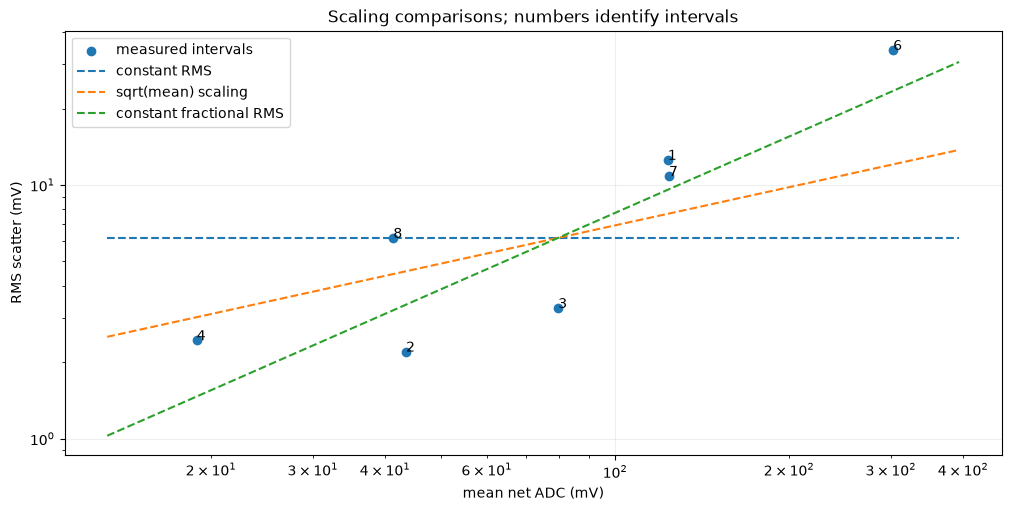

In [39]:
ENBW_SCENARIOS_HZ = np.array([5.0, 10.0, 20.0, 40.0])
q_e = 1.602176634e-19
shot_rows = []
if statistics:
    for i, stats in enumerate(statistics):
        if stats["mean_mv"] <= 0:
            continue
        for bandwidth in ENBW_SCENARIOS_HZ:
            shot_mv = np.sqrt(2*q_e*EFFECTIVE_GAIN_V_PER_A*(stats["mean_mv"]/1000)*bandwidth)*1000
            shot_rows.append(dict(interval=i, enbw_hz=bandwidth, shot_rms_mv=shot_mv,
                                  observed_rms_mv=stats["rms_mv"], ratio=stats["rms_mv"]/shot_mv))
    display(pd.DataFrame(shot_rows))
    bright = summary.loc[summary.mean_mv > 3*summary.rms_mv]
    if not bright.empty:
        fig, ax = plt.subplots(layout="constrained")
        ax.scatter(bright.mean_mv, bright.rms_mv, label="measured intervals")
        for row in bright.itertuples():
            ax.annotate(str(row.interval), (row.mean_mv, row.rms_mv))
        mu0, rms0 = bright.mean_mv.median(), bright.rms_mv.median()
        mu = np.geomspace(max(bright.mean_mv.min()*.7, .01), bright.mean_mv.max()*1.3, 200)
        for exponent, label in [(0, "constant RMS"), (.5, "sqrt(mean) scaling"), (1, "constant fractional RMS")]:
            ax.plot(mu, rms0*(mu/mu0)**exponent, "--", label=label)
        ax.set(xscale="log", yscale="log", xlabel="mean net ADC (mV)", ylabel="RMS scatter (mV)", title="Scaling comparisons; numbers identify intervals")
        ax.legend()
        plt.show()
else:
    print("Shot-noise and brightness comparisons need fixed-setting records; no historical summary substituted.")

### Throughput and uncertainty accounting

The current stream already applies its recorded return loss to `pd_power_nw` and its recorded launch
loss to `delivered_power_nw`. First check their arithmetic, then ask whether those routes describe
the physical bypass. For the selected alternative geometry,

$$T_{bypass}=T_{recorded}\,
\frac{pd\_route\_tx}{RETURN\_TX}\,
\frac{laser\_route\_tx}{10^{-STATIC\_LOSS\_DB/10}}.$$

This is a **geometry scenario** for historical data, not a retroactive measurement of its setup.
The path factors are latched when monitoring starts. Correcting their values afterward on the PCB
does not alter an already running stream or old records.

If an associated power-meter reading is supplied, a second calculation replaces the source-power
estimate. It still depends on attenuator calibration and detector response. A stable laser can have
an uncertain absolute power estimate. No route or calibration uncertainty is invented below.

,tp_max_abs_arithmetic_difference,tp_pd_err_max_abs_difference,tp_err_max_abs_difference,median_recorded_launch_tx,median_recorded_return_tx,bypass_multiplier
0,1.720935e-11,6.389200e-11,6.397727e-11,0.000008,0.98,0.0024


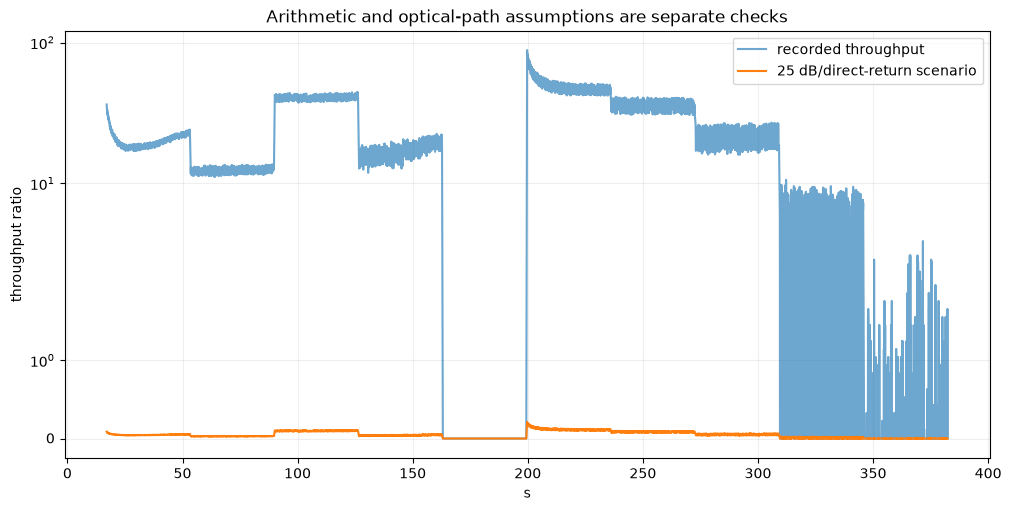

,interval,illuminated_scatter_mv,reported_pd_error_mv,block_duration_s,block_mean_scatter_mv,source_uncertainty_fraction
0,0,0.360834,323.471875,1.0,0.190832,NaN
1,1,12.559331,323.471875,1.0,11.968328,0.198544
2,2,2.203158,323.471875,1.0,0.749584,0.179886
3,3,3.269862,323.471875,1.0,1.151871,0.144405
4,4,2.441539,323.471875,1.0,1.634562,0.232975
5,5,0.762470,323.471875,1.0,0.402997,0.234377
6,6,34.039133,323.471875,1.0,29.163408,0.140687
7,7,10.849071,323.471875,1.0,3.863657,0.134543
8,8,6.183747,323.471875,1.0,1.958205,0.165981
9,9,4.167764,323.471875,1.0,1.218088,0.168275


Source uncertainty may include the firmware's assumed electrical-noise term; it is not all shared calibration error.


In [40]:
audit_fields = {"tp", "tp_err", "tp_pd_err", "pd_power_nw", "pd_power_err_nw",
    "delivered_power_nw", "delivered_power_err_nw", "pd_route_tx", "laser_route_tx", "atten_tx"}
if not data.empty and audit_fields <= set(data):
    if not np.isfinite(STATIC_LOSS_DB) or not 0 < RETURN_TX <= 1:
        raise ValueError("Specify finite physical static loss and 0 < RETURN_TX <= 1.")
    d = data.loc[np.isfinite(data.delivered_power_nw) & (data.delivered_power_nw > 0)].copy()
    with np.errstate(divide="ignore", invalid="ignore"):
        reconstructed_tp = d.pd_power_nw/d.delivered_power_nw
        reconstructed_pd_err = d.pd_power_err_nw/d.delivered_power_nw
        reconstructed_err = np.hypot(reconstructed_pd_err,
            reconstructed_tp*d.delivered_power_err_nw/d.delivered_power_nw)
        route_factor = d.pd_route_tx/RETURN_TX * d.laser_route_tx/10**(-STATIC_LOSS_DB/10)
        d["tp_bypass"] = d.tp*route_factor
        d["err_bypass"] = d.tp_err*route_factor
    display(pd.DataFrame([dict(
        tp_max_abs_arithmetic_difference=float((d.tp-reconstructed_tp).abs().max()),
        tp_pd_err_max_abs_difference=float((d.tp_pd_err-reconstructed_pd_err).abs().max()),
        tp_err_max_abs_difference=float((d.tp_err-reconstructed_err).abs().max()),
        median_recorded_launch_tx=d.laser_route_tx.median(), median_recorded_return_tx=d.pd_route_tx.median(),
        bypass_multiplier=route_factor.median())]))
    fig, ax = plt.subplots(layout="constrained")
    t = (d.t_ms-data.t_ms.iloc[0])/1000
    ax.plot(t, d.tp, label="recorded throughput", alpha=.65)
    ax.plot(t, d.tp_bypass, label="25 dB/direct-return scenario" if STATIC_LOSS_DB == 25 else "selected geometry scenario")
    if EXTERNAL_LASER_POWER_MW is not None:
        if not EXTERNAL_LASER_POWER_MW > 0:
            raise ValueError("Power-meter reading must be positive.")
        meter_denominator = EXTERNAL_LASER_POWER_MW*1e6*d.atten_tx*10**(-STATIC_LOSS_DB/10)
        ax.plot(t, d.pd_power_nw*d.pd_route_tx/RETURN_TX/meter_denominator, label="geometry + supplied power-meter value")
    ax.set(yscale="symlog", ylabel="throughput ratio", xlabel="s", title="Arithmetic and optical-path assumptions are separate checks")
    ax.legend()
    plt.show()
else:
    print("Current power/error fields unavailable; route/error audit skipped.")

error_rows = []
for i,(part,stats) in enumerate(zip(segments, statistics)):
    b = stats["blocks"]
    one = b.iloc[np.argmin(abs(b.tau_s-1))] if len(b) else None
    error_rows.append(dict(interval=i, illuminated_scatter_mv=stats["rms_mv"],
        reported_pd_error_mv=part.pd_net_err_mv.median() if "pd_net_err_mv" in part else np.nan,
        block_duration_s=one.tau_s if one is not None else np.nan,
        block_mean_scatter_mv=one.rms_mean_mv if one is not None else np.nan,
        source_uncertainty_fraction=(part.delivered_power_err_nw/part.delivered_power_nw.where(part.delivered_power_nw>0)).median()
            if "delivered_power_err_nw" in part else np.nan))
if error_rows:
    display(pd.DataFrame(error_rows))
    print("Source uncertainty may include the firmware's assumed electrical-noise term; it is not all shared calibration error.")

Near darkness, tiny positive zero-clipped power or throughput is not evidence of a detection.
Use the signed voltage, a nearby dark trace, and measured averaging stability. The noise summary
suppresses fractional RMS when the mean is below three times the individual-reading scatter;
that is a descriptive reporting threshold, not a calibrated significance test for a time average.

To investigate a large absolute throughput offset, check the power meter, responsivity/effective
gain, static attenuation, and couplings after correcting geometry. The new electrical-noise term
does not correct an erroneous mean denominator.

When local candidate voltage commands were used, firmware still reports attenuation and throughput
using its installed coefficients. The additional experimental-curve line explicitly replaces that
dynamic attenuation factor offline; it is a candidate estimate, not an independent power measurement.

<a id="scope"></a>
## 5. Local slopes: how much voltage noise would matter?

All scope voltages below are **post-amplifier FVOA-control mV**, not DAC mV. Let
$s_i=dA_i/dV_i$ be dB per FVOA mV and $k=\ln(10)/10$. At frequencies where the optical response follows
the drive, the predicted fractional intensity variance is

$$\sigma_{rel}^2=k^2\left[(s_1\sigma_1)^2+(s_2\sigma_2)^2+
2\rho s_1s_2\sigma_1\sigma_2\right].$$

The equal-independent-drive inversion is only an **equivalent voltage noise**: it attributes all
remaining optical scatter to the drives. It does not measure the drives or prove causality.
Stored fit residuals describe curve uncertainty and are not added to temporal RMS here.

In [41]:
def drive_slopes(coefficients, dac_mv):
    slopes = []
    for physical, mv in zip(("dac1", "dac2"), dac_mv):
        coeff = coefficients[physical]
        gain = float(coeff["gain"])
        x = float(mv) + np.array([-.1, .1])/gain
        db = hspcb._atten_db_from_coeff((coeff["fvoa_50pct_mv"], coeff["slope_inv_fvoa_mv"],
            coeff["max_atten_db"], gain, tuple(coeff["correction_coeff"]),
            float(coeff.get("max_calibrated_db", 0.0))), x)
        slopes.append(float((db[1]-db[0])/.2))
    return np.asarray(slopes)


equivalent_rows = []
noise_context = noise_meta.get("context", {})
coefficients = noise_context.get("coeff")
dark_stats = [stats for part,stats in zip(segments, statistics)
              if "step_label" in part and part.step_label.iloc[0] == "dark"]
dark_rms = dark_stats[0]["rms_mv"] if dark_stats else np.nan
for i,(part,stats) in enumerate(zip(segments, statistics)):
    if coefficients is None or "step_index" not in part or not np.isfinite(stats["relative_rms"]):
        continue
    step = next(s for s in noise_meta["steps"] if s["index"] == int(part.step_index.iloc[0]))
    if step["label"] == "dark":
        continue
    state = step["state"]
    slopes = drive_slopes(coefficients, (state["v1_mv"], state["v2_mv"]))
    scale = np.log(10)/10
    excess = np.sqrt(max(stats["rms_mv"]**2-dark_rms**2, 0)) if np.isfinite(dark_rms) else stats["rms_mv"]
    equivalent = excess/abs(stats["mean_mv"])/(scale*np.linalg.norm(slopes)) if np.linalg.norm(slopes)>0 else np.nan
    equivalent_rows.append(dict(interval=i, step=step["label"], mv=stats["mean_mv"], rms_mv=stats["rms_mv"], slope1_db_per_fvoa_mv=slopes[0],
        slope2_db_per_fvoa_mv=slopes[1], equivalent_equal_independent_rms_mv=equivalent,
        rms_over_mean=stats["relative_rms"], predicted_fraction_at_1mv=scale*np.linalg.norm(slopes),
        installed_curve_sigma_fraction=scale*np.hypot(coefficients["dac1"]["rms_db"], coefficients["dac2"]["rms_db"])))
if equivalent_rows:
    display(pd.DataFrame(equivalent_rows))
else:
    print("Slope/noise inference needs a capture sidecar with coefficients and actual per-FVOA DAC positions.")

# Static sensitivity scenarios. None means no actual scope RMS has been supplied.
SCOPE_RMS_MV = None  # e.g. (sigma1, sigma2), measured RMS in the stated relevant bandwidth.
DRIVE_CORRELATION = 0.0
if SCOPE_RMS_MV is not None and equivalent_rows:
    if len(SCOPE_RMS_MV) != 2 or min(SCOPE_RMS_MV) < 0 or not -1 <= DRIVE_CORRELATION <= 1:
        raise ValueError("Supply two nonnegative RMS values and a correlation from -1 to 1.")
    s = equivalent_rows[0]
    a,b = np.array([s["slope1_db_per_fvoa_mv"],s["slope2_db_per_fvoa_mv"]])*SCOPE_RMS_MV
    predicted = np.log(10)/10*np.sqrt(max(a*a+b*b+2*DRIVE_CORRELATION*a*b, 0))
    print(f"Static prediction for interval {s['interval']}: {100*predicted:.2f}% RMS; bandwidth assumptions still apply.")

,interval,step,mv,rms_mv,slope1_db_per_fvoa_mv,slope2_db_per_fvoa_mv,equivalent_equal_independent_rms_mv,rms_over_mean,predicted_fraction_at_1mv,installed_curve_sigma_fraction
0,1,50.0 a1,123.322961,12.559331,0.080788,0.000000,5.472430,0.101841,0.018602,0.062111
1,2,52.5 a1,43.466046,2.203158,0.072076,0.000000,3.012884,0.050687,0.016596,0.062111
2,3,55.0 a1,79.689702,3.269862,0.054998,0.000000,3.220366,0.041032,0.012664,0.062111
3,4,57.5 a1,18.884393,2.441539,0.096587,0.000000,5.749503,0.129289,0.022240,0.062111
4,5,60.0 a1,-30.912075,0.762470,0.097224,0.000000,0.970611,0.024666,0.022387,0.062111
5,6,50.0 a2,302.649202,34.039133,0.000000,0.053149,9.189716,0.112471,0.012238,0.062111
6,7,52.5 a2,123.877674,10.849071,0.000000,0.050059,7.593813,0.087579,0.011527,0.062111
7,8,55.0 a2,41.324470,6.183747,0.000000,0.065482,9.907544,0.149639,0.015078,0.062111


PCB warning laserbank_heater_override: laser bank heater override is active; automatic warmup is disabled context=override_on uptime_ms=604451
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=614.119 threshold_mv=10.000 uptime_ms=615021
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=45.567 threshold_mv=10.000 uptime_ms=1817271
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=hk fixed_rms_mv=10.937 threshold_mv=10.000 uptime_ms=1817688


## 6. What evidence would change the design?

| Observation | Interpretation / next check |
|---|---|
| Firmware chooses fewer correction terms | Inspect calibrated-region residuals; the higher-order correction failed the curve check. |
| Firmware reports base-only fit | Inspect its residuals and rejection warning before relying on dB accuracy. |
| Initial reference and first sweep reading disagree at the same settings | Inspect the chronological probe table and acquisition timing; the cause remains unresolved. |
| Equal-total allocations change fractional noise with local slopes | Consistent with drive sensitivity; compare actual detector levels and simultaneous voltage spectra. |
| Drive and analog-PD spectra are coherent at the excess-noise frequencies | Quantify gain, phase and both-drive covariance; test filtering in that band. Coherence alone does not establish causality. |
| Analog PD is quiet while ADC varies | Investigate detector-output-to-ADC path, reference, pickup and conversion configuration. |
| Analog PD varies without resolved drive variation | Bound the scope floor; investigate actuator/mechanical/thermal or detector multiplicative noise. |
| Repeated reference settings drift | Separate drift from stationary noise; use longer repeats and logged temperature before fitting a brightness law. |
| Route correction fixes the mean but not scatter | Geometry explained the scale error; noise and absolute response calibration remain separate. |

Before changing an op-amp/DAC filter, establish how much **in-band** voltage variation accounts for
the optical scatter. The present evidence motivates that measurement; it does not establish a PCB respin.

### References in this workspace

- [Current calibration and acquisition](../doc/attenuator_calibration.md)
- [Photodiode sampling and uncertainty assumptions](../doc/photodiode_notes.md)
- [Installed attenuator slope/noise calculation](../doc/api/attenuator_control.md)
- [Command/API units and side effects](../doc/commands.md)
- [Analog hardware and gain locations](../doc/hardware.md)